# The gallery, live: held-out scoring through the public API

Every number in this notebook is produced by a live fit. Nothing here reads
`analysis/results/*.csv`.

The path is always the same four steps, and it is the whole point of the notebook:

```
gallery.fit(name, triangle, ...)          # a fitted GalleryEntry
  -> entry.log_lik_at(cells, field=...)   # ScoresHeldout  -> (draws, cells) log densities
  -> entry.predict_at(cells, field=...)   # PredictsHeldout -> (draws, cells) loss draws
  -> kernels.forecast.align_panel(...)    # one identical cell set per score
  -> gallery.leaderboard(panel)           # the board
```

`02_transformer_vs_statistical.ipynb` reads the published retrospectives and tells the
research story over 152 cohorts. This notebook does the opposite: a small panel, one
cutoff, one field, and every step executed in front of you so the API and the
milestone-6 leaderboard semantics are visible rather than described.

**It is also the gallery's introduction to the neural entry.** The research interest in
`nn_transformer` is the network, and a `gallery.fit` call hides it completely, so a section
in the middle of this notebook - *Inside the transformer*, placed immediately before the NN
fits so a reader meets the model before its results - opens it up: the `nn_data` contract
that feeds it, `TriangleTransformer.__init__` and `forward`, the measured parameter count,
the mixture density head and its loss, and the training scheme. Every block of code there is
printed from the live module with `inspect.getsource`, so none of it can drift from what
runs. A short follow-up after the fits shows the same cell's *learned* mixture and the
autoregressive rollout that turns per-cell mixtures into ultimates.

**What it costs.** About 20 minutes of fitting on the dev box, dominated by
`compartmental` (a hierarchical ODE-style model at relaxed sampler settings) and
`guszcza_growth_curve`. The per-family timings, and the measured total for the run
committed here, are printed in the last cell. The transformer section adds
seconds rather than minutes: it builds a network and reads the fitted one, and trains nothing
of its own.

**What it is not.** 25 cohorts at one cutoff on one field is a demonstration, not a
study. The evidence lives in the 200-company retrospectives
(`scripts/meyers_validation.py`, `scripts/compare_gallery.py`) and in notebook 02. The
closing section says explicitly what this notebook does and does not claim.

In [1]:
import datetime as dt
import logging
import platform
import sys
import time
import warnings
from pathlib import Path

import ibis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cmdstanpy.utils import get_logger as cmdstan_logger
from matplotlib.patches import Patch

import ibnr
from ibnr import gallery
from ibnr.data.schedule_p import (
    active_mart_path,
    active_publish_id,
    load_schedule_p,
    pinned_source,
)
from ibnr.gallery import (
    SCORE_DIRECTION,
    Absence,
    CohortForecast,
    align_panel,
    next_diagonal,
)
from ibnr.gallery.entry import PredictsHeldout, ScoresHeldout
from ibnr.kernels.calibration import ks_uniformity, pp_points

warnings.filterwarnings("ignore")

# cmdstanpy installs its own INFO StreamHandler the first time a model is USED,
# which would override a level set at import time. Reaching for the logger
# through cmdstanpy's own accessor forces that setup to happen now, so the level
# sticks. Without this, guszcza_growth_curve and compartmental alone emit
# hundreds of init-rejection lines and the committed notebook is unreadable.
_lg = cmdstan_logger()
_lg.setLevel(logging.ERROR)
for _h in _lg.handlers:
    _h.setLevel(logging.ERROR)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# --- switches ---------------------------------------------------------------
RUN_COMPARTMENTAL = True  # ~13-20 min; the only high-variance line item
RUN_REPORTED_APPENDIX = True  # ~3 min; meyers_ccl / meyers_csr on reported_loss

# --- the one cutoff, the one field ------------------------------------------
AS_OF = dt.date(1997, 12, 31)
FIELD = "paid_loss"
TASK = f"{FIELD}@1997"
PREMIUM_FIELD = "earned_premium"
# THE STUDY WINDOW. The triangle itself is cut to these accident years before
# anything is fitted, so every fit and every held-out cell rest on the same
# data - see "The study window" below. Accident years 1988 and 1989 are out of
# the study entirely; they are not merely left unscored.
ORIGINS = [dt.date(y, 1, 1) for y in range(1990, 1998)]
SEED_FIT = 11  # every sampler / bootstrap / torch init
SEED_DRAW = 7  # every predict_at() and predict() call

# --- provenance -------------------------------------------------------------
SOURCE = pinned_source()  # never resolves @latest, never calls gh
PUBLISH_ID = active_publish_id()
print("ibnr           ", ibnr.__version__)
print("python         ", sys.version.split()[0], platform.platform())
print("mart source    ", SOURCE)
print("mart publish_id", PUBLISH_ID)
print("mart parquet   ", active_mart_path(SOURCE).name)

C:\Users\EthanKang\Projects\ibnr\.claude\worktrees\nb03\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ibnr            0.5.2
python          3.12.13 Windows-11-10.0.26200-SP0
mart source     github://EKtheSage/cas-schedule-p-data-model@20260613_041006
mart publish_id 20260613_041006
mart parquet    mart_reserving_model_training.parquet


## The panel

Two mechanical screens, both re-derived below from the mart rather than pasted in.

1. **The milestone-3 / Meyers screen** (`scripts/meyers_validation.select_companies`,
   the monograph's Table A.1): CV of net earned premium, CV of the net/direct premium
   ratio, a complete 10x10 square, a premium and loss floor, and Meyers' one excluded
   group. Run on all four lines it passes 60 companies on two or more lines - the 152
   `(company, line)` pairs the milestone-3 study scored.

2. **An ODP positivity screen.** `england_verrall_odp` legitimately refuses a cohort
   with a negative paid increment: the over-dispersed Poisson quasi-likelihood is not
   defined there. That is a documented family limit, not a bug. Of the 152 pairs only
   some are clean, and only **10 companies are clean on every one of their screened
   lines**. The screen reads the whole 1988-1997 history rather than the study
   window defined below: a cohort clean over ten accident years is clean over the
   eight the study keeps, so it is strictly conservative, and it keeps this panel
   identical to the one the published board ran on.

Selecting whole clean **companies** rather than clean **pairs** is deliberate. It keeps
ODP on the board with zero refusals, so every model is asked about exactly the same 25
cohorts (the cohort-data parity rule); and it leaves each company with two or more lines,
which is what the multiline appendix at the end needs.

The size range is wide on purpose: over the study window the largest cohort carries
about twelve million (USD thousands) of mean earned premium and the smallest a couple
of hundred, so the board is not a study of one magnitude.

In [2]:
# scripts/ is not an installed package, so the screen is imported by path rather
# than copied - a copy would drift from the script that produced the published
# retrospectives, and then the panel would silently stop being the study's panel.
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(REPO / "scripts"))
from meyers_validation import MEYERS_LINES, select_companies  # noqa: E402

MART = active_mart_path(SOURCE)

t0 = time.perf_counter()
passing = {ln: set(select_companies(MART, ln, 10_000)["company_code"]) for ln in MEYERS_LINES}
by_company: dict[str, list[str]] = {}
for ln, codes in passing.items():
    for c in codes:
        by_company.setdefault(c, []).append(ln)
multiline = {c: sorted(ls) for c, ls in by_company.items() if len(ls) >= 2}
print({ln: len(v) for ln, v in passing.items()})
print(
    f"companies passing on >=2 lines: {len(multiline)}  pairs: {sum(map(len, multiline.values()))}"
)

# --- ODP positivity screen on the <=1997 training slice ----------------------
# Deliberately over the FULL 1988-1997 history rather than the study window
# below. It is strictly conservative - a cohort with no negative paid increment
# over ten accident years has none over the eight the study keeps - and running
# it on the wider history is what keeps this panel identical to the one the
# published board used, so the two are comparable cohort for cohort.
scan = load_schedule_p(SOURCE, lines=MEYERS_LINES, companies=sorted(multiline)).expr.execute()
scan["eval_date"] = pd.to_datetime(scan["eval_date"])
scan["origin_period"] = pd.to_datetime(scan["origin_period"])
paid_train = scan[
    (scan["field"] == FIELD)
    & (scan["eval_date"] <= pd.Timestamp(AS_OF))
    & (scan["origin_period"].dt.year.between(1988, 1997))
]
clean_pairs = set()
for key, g in paid_train.groupby(["company_code", "line_of_business"]):
    increments = [
        np.diff(np.r_[0.0, gg.sort_values("dev_lag")["value"].to_numpy()])
        for _, gg in g.groupby("origin_period")
    ]
    if all((inc >= 0).all() for inc in increments):
        clean_pairs.add(key)
print(f"pairs with no negative paid increment in the training slice: {len(clean_pairs)}")

PANEL = {c: ls for c, ls in sorted(multiline.items()) if all((c, ln) in clean_pairs for ln in ls)}
COHORTS = [(c, ln) for c, ls in PANEL.items() for ln in ls]
LINES = sorted({ln for ls in PANEL.values() for ln in ls})
print(f"screens took {time.perf_counter() - t0:.1f}s")

# Recorded, so a future gold publish that moves the panel is LOUD rather than a
# board that silently compares different insurers to the published one.
EXPECTED_PANEL = {
    "10022": ["commercial_auto", "private_passenger_auto"],
    "14044": ["commercial_auto", "other_liability", "private_passenger_auto"],
    "1767": [
        "commercial_auto",
        "other_liability",
        "private_passenger_auto",
        "workers_compensation",
    ],
    "18767": ["commercial_auto", "workers_compensation"],
    "2003": ["other_liability", "private_passenger_auto"],
    "25275": ["commercial_auto", "private_passenger_auto"],
    "27022": ["commercial_auto", "private_passenger_auto"],
    "2712": ["commercial_auto", "workers_compensation"],
    "620": ["commercial_auto", "other_liability", "private_passenger_auto"],
    "7080": ["commercial_auto", "private_passenger_auto", "workers_compensation"],
}
assert PANEL == EXPECTED_PANEL, f"panel moved under publish_id {PUBLISH_ID}: {PANEL}"
print(f"\n{len(PANEL)} companies, {len(COHORTS)} cohorts, {len(LINES)} lines")
for c, ls in PANEL.items():
    print(f"  {c:>6}  {', '.join(ls)}")

{'commercial_auto': 63, 'private_passenger_auto': 60, 'workers_compensation': 52, 'other_liability': 56}
companies passing on >=2 lines: 60  pairs: 152


pairs with no negative paid increment in the training slice: 87
screens took 1.8s

10 companies, 25 cohorts, 4 lines
   10022  commercial_auto, private_passenger_auto
   14044  commercial_auto, other_liability, private_passenger_auto
    1767  commercial_auto, other_liability, private_passenger_auto, workers_compensation
   18767  commercial_auto, workers_compensation
    2003  other_liability, private_passenger_auto
   25275  commercial_auto, private_passenger_auto
   27022  commercial_auto, private_passenger_auto
    2712  commercial_auto, workers_compensation
     620  commercial_auto, other_liability, private_passenger_auto
    7080  commercial_auto, private_passenger_auto, workers_compensation


In [3]:
t0 = time.perf_counter()
tri_all = load_schedule_p(SOURCE, companies=list(PANEL), lines=LINES)

# load_schedule_p returns the cross product of companies x lines; keep only the
# 25 screened pairs.
_e = tri_all.expr
_keep = ibis.literal(False)
for c, ls in PANEL.items():
    for ln in ls:
        _keep = _keep | ((_e.company_code == c) & (_e.line_of_business == ln))
tri_full = tri_all.filter(_keep)

# The mart's display segment is dropped, and this is STILL load-bearing in 0.5.2 -
# checked by removing it and re-executing, which fails. Worth stating precisely,
# because 0.5.0 fixed a neighbouring thing and it is easy to assume it fixed this.
#
# The mart carries three segments; kernels.nn_contract treats company_name as
# display-only, so a pooled NN fit is keyed on two. What 0.5.0 added is narrowing
# INSIDE the capability mixins: entry.at_cohort(seg).log_lik_at(wide_cells) now
# re-keys the cells onto the view's schema (HoldoutCells.narrowed_to), verifying
# each dropped value against the fitted cohort first. Two calls this notebook
# makes are not on that path:
#
#   * index_into(cells, view.contract_) DIRECTLY, in the mixture-head cell below.
#     index_into demands exact schema equality by design - it is the check that
#     stops a fit keyed on one column vouching for cells keyed on two - and the
#     narrowing sits one level above it, not inside it.
#   * log_lik_at on the POOLED entry rather than on a cohort view. nn_data's
#     contract has no `segment` key at all (only `segment_columns`), so the
#     mixin has no single-cohort identity to verify a dropped value against and
#     passes the cells through untouched.
#
# Dropping the column here keeps both paths on one schema. It costs the Stan
# entries nothing (they accept either).
tri_full = tri_full.with_expr(tri_full.expr.drop("company_name"))

# THE STUDY WINDOW, cut into the DATA and not into the scoring call. Everything
# downstream - every fit, every next_diagonal, every realized ultimate - reads
# `tri`, so "what the fits trained on" and "what the held-out census calls
# training" are the same table by construction instead of two arguments that
# have to be kept in agreement. `tri_full` survives only as the thing the window
# was cut from; nothing on the board reads it.
tri = tri_full.filter(tri_full.expr.origin_period.isin(ORIGINS))
print("segments:", tri.segments)
print(f"{tri_full.count()} rows loaded in {time.perf_counter() - t0:.1f}s")
assert sorted(tri.origins) == ORIGINS, sorted(tri.origins)
print(
    f"{tri.count()} rows inside the study window: accident years "
    f"{ORIGINS[0].year}-{ORIGINS[-1].year} ({len(ORIGINS)} of them)"
)

_frame = tri.expr.execute()
_frame["origin_period"] = pd.to_datetime(_frame["origin_period"])
# No year filter here any more: the triangle IS the window.
_prem = _frame[_frame["field"] == PREMIUM_FIELD]
_paid_latest = _frame[
    (_frame["field"] == FIELD) & (pd.to_datetime(_frame["eval_date"]) == pd.Timestamp(AS_OF))
]
pairs_table = (
    _prem.groupby(["company_code", "line_of_business"])["value"]
    .mean()
    .rename("mean_earned_premium")
    .to_frame()
    .join(
        _paid_latest.groupby(["company_code", "line_of_business"])["value"]
        .sum()
        .rename("paid_at_1997")
    )
    .reset_index()
    .sort_values("mean_earned_premium", ascending=False)
    .reset_index(drop=True)
)
print("\nunits:", tri.meta.units)
pairs_table.round(0)

segments: ['company_code', 'line_of_business']
35000 rows loaded in 0.2s


14000 rows inside the study window: accident years 1990-1997 (8 of them)

units: USD thousands


,company_code,line_of_business,mean_earned_premium,paid_at_1997
0,1767,private_passenger_auto,12635198.0,65271145.0
1,2003,private_passenger_auto,1897574.0,8778907.0
2,1767,commercial_auto,368564.0,1479179.0
3,1767,workers_compensation,315899.0,1162383.0
4,7080,workers_compensation,291281.0,1147580.0
5,1767,other_liability,264061.0,1150600.0
6,7080,private_passenger_auto,205590.0,805616.0
7,2712,workers_compensation,90936.0,351754.0
8,620,other_liability,77036.0,228301.0
9,2003,other_liability,71516.0,127602.0


## The held-out question

`kernels.holdout.next_diagonal(triangle, as_of=..., fields=...)` answers one question:
**given a fit trained on everything visible at `as_of`, which cells is it scored on?**
The answer is the next calendar diagonal, one cohort at a time, with the next
development lag `D_next` read from the data rather than assumed. Cells the fit could not
have known about are excluded and the reason is counted, not dropped silently
(`new_origin`, `dev_beyond_trained`, ...).

Two choices below are load-bearing.

**`fields=["paid_loss", "reported_loss"]` for every cohort, even though the board is on
paid.** `compartmental` is a joint paid-and-outstanding model and needs both. Mixing
one-field and two-field `HoldoutCells` on the same panel makes `align_panel` raise -
the second field contributes its own exclusions, so two models end up disagreeing about
the exclusion census for the same cohort, which is `align_panel`'s way of saying they
were not asked the same question. Building every cohort's cells **once** with both
fields and passing `field="paid_loss"` explicitly to `log_lik_at`, `predict_at` and
`CohortForecast` is what keeps the census identical. So `n_cells` reads 14 while the
paid narrowing gives 7, and that is correct.

**No `origins=` argument, because the triangle is already the study window.**
`next_diagonal` has one, and reaching for it here would be a mistake: it restricts the
*training* claims the census is computed from as well as the cells to be scored, so the
returned `HoldoutCells` would describe a training window narrower than the one the fits
actually consumed - `dev_beyond_trained` exclusions that no fit ever earned, and a
provenance claim that is not the fits'. Accident years 1988 and 1989 are instead cut out
of `tri` before anything is fitted. `HoldoutCells.train_origins` is asserted below
against `ORIGINS` for all 25 cohorts, so the census and the fits cannot drift apart.

**Why the window starts at 1990.** It is inherited from the earlier run of this notebook,
where scoring stopped at 1990 while the fits still saw 1988 - the mismatch this version
removes - and keeping the same eight accident years keeps the two boards comparable cell
for cell. Under a consistent window it buys nothing else, and the section after the fits
shows why: the deepest scored cell always sits at the fit's own development frontier, at
any window. So 1990 is now simply a study choice, and its cost - the two deepest
development lags, where a growth-curve or CSR-style model is most distinctive - is
caveat 5 in the closing section.

That leaves **7 held-out paid cells per cohort, 175 offered in total.** How many of those
each score actually rests on is decided later, by the intersection over that score's own
members - see "What the panel cost" below.


In [4]:
t0 = time.perf_counter()
sub: dict[tuple[str, str], object] = {}
cells: dict[tuple[str, str], object] = {}
for c, ln in COHORTS:
    s = tri.filter((tri.expr.company_code == c) & (tri.expr.line_of_business == ln))
    sub[(c, ln)] = s
    cells[(c, ln)] = next_diagonal(
        s,
        as_of=AS_OF,
        fields=[FIELD, "reported_loss"],  # both, so compartmental shares the census
        premium_field=PREMIUM_FIELD,
    )
print(f"25 x next_diagonal in {time.perf_counter() - t0:.1f}s")

_one = cells[COHORTS[0]]
print(
    f"\n{COHORTS[0]}: n_cells={_one.n_cells} (both fields), "
    f"paid={(_one.frame['field'] == FIELD).sum()}"
)
print("as_of      ", _one.as_of)
print("eval_date  ", _one.eval_date)
print("measure    ", _one.measure)
print("segments   ", _one.segments)
print("exclusions ", _one.exclusion_counts())

# THE PROVENANCE CHECK, and the reason this notebook was rebuilt. train_origins
# is what the held-out census believes the fit was trained on. It has to be the
# study window itself, on every cohort, or the board scores one training set and
# describes another.
assert all(list(v.train_origins) == ORIGINS for v in cells.values())
print("train_origins  ", f"{_one.train_origins[0]} .. {_one.train_origins[-1]}", "(all 25 cohorts)")

_counts = {k: int((v.frame["field"] == FIELD).sum()) for k, v in cells.items()}
print(
    "paid cells per cohort:", sorted(set(_counts.values())), "| panel total:", sum(_counts.values())
)
_one.frame[_one.frame["field"] == FIELD]

25 x next_diagonal in 12.6s

('10022', 'commercial_auto'): n_cells=14 (both fields), paid=7
as_of       1997-12-31
eval_date   1998-12-31
measure     cumulative
segments    ('company_code', 'line_of_business')
exclusions  {'new_origin': 0, 'dev_beyond_trained': 2, 'no_predecessor': 0}
train_origins   1990-01-01 .. 1997-01-01 (all 25 cohorts)
paid cells per cohort: [7] | panel total: 175


,company_code,line_of_business,field,origin_period,dev_lag,eval_date,value,prev_value,premium
0,10022,commercial_auto,paid_loss,1991-01-01,96,1998-12-31,792.0,790.0,1061.0
1,10022,commercial_auto,paid_loss,1992-01-01,84,1998-12-31,626.0,623.0,1281.0
2,10022,commercial_auto,paid_loss,1993-01-01,72,1998-12-31,861.0,852.0,1393.0
3,10022,commercial_auto,paid_loss,1994-01-01,60,1998-12-31,842.0,806.0,1692.0
4,10022,commercial_auto,paid_loss,1995-01-01,48,1998-12-31,410.0,386.0,1371.0
5,10022,commercial_auto,paid_loss,1996-01-01,36,1998-12-31,331.0,252.0,1360.0
6,10022,commercial_auto,paid_loss,1997-01-01,24,1998-12-31,468.0,276.0,1652.0


## The roster: who can be scored on what

Milestone 6 splits a forecast into **two independent capabilities**, and the split is the
reason this board can be honest about entries with very different shapes:

* `ScoresHeldout` -> `log_lik_at()` -> a normalized predictive **density** -> **ELPD**;
* `PredictsHeldout` -> `predict_at()` -> predictive **draws** -> **CRPS**.

An entry may have either, both, or neither, and the two are not redundant.
`england_verrall_odp` draws perfectly well but its over-dispersed Poisson
quasi-likelihood is only a density up to proportionality, so it has no ELPD ever.
`deterministic/mack`'s bootstrap has no stated observation model, same conclusion by a
different route. The roster below is built from the live registry, not typed out.

Three entries - `sur`, `copula_glm`, `nn_transformer_ml` - subclass **neither** mixin.
They cannot appear in either score column at all, so they get an ultimate-level appendix
at the end instead of a board row. That is a gap in the entries, not in the panel, and
the leaderboard would say so with the reason `scorer_not_implemented` if they were
handed to it.

In [5]:
roster = (
    pd.DataFrame(
        [
            {
                "entry": name,
                "family": cls.family,
                "density (ELPD)": issubclass(cls, ScoresHeldout),
                "draws (CRPS)": issubclass(cls, PredictsHeldout),
            }
            for name in gallery.list()
            for cls in [gallery.get(name)]
        ]
    )
    .sort_values(["family", "entry"])
    .reset_index(drop=True)
)
print(
    f"{len(roster)} registered entries; "
    f"{roster['density (ELPD)'].sum()} density, {roster['draws (CRPS)'].sum()} draws, "
    f"{(~roster['density (ELPD)'] & ~roster['draws (CRPS)']).sum()} neither"
)
roster

15 registered entries; 8 density, 12 draws, 3 neither


,entry,family,density (ELPD),draws (CRPS)
0,clark_growth_curve,bayesian,False,True
1,compartmental,bayesian,True,True
2,england_verrall_odp,bayesian,False,True
3,guszcza_growth_curve,bayesian,True,True
4,meyers_ccl,bayesian,True,True
5,meyers_csr,bayesian,True,True
6,mack,deterministic,False,True
7,deeptriangle,nn,True,True
8,mdn,nn,True,True
9,nn_transformer,nn,True,True


In [6]:
# The methods section, in one dict. Every entry on the board is fitted with
# exactly these arguments - nothing is tuned per cohort.
PER_COHORT_CONFIG = {
    "mack": dict(sigma_rule="mack", heldout_n_draws=10_000),
    "clark": dict(growth_curve="loglogistic", method="cape_cod"),
    "meyers_ccl": dict(seed=SEED_FIT, parallel_chains=4),
    "meyers_csr": dict(seed=SEED_FIT, parallel_chains=4),
    "england_verrall_odp": dict(seed=SEED_FIT, parallel_chains=4),
    "clark_growth_curve": dict(seed=SEED_FIT, parallel_chains=4, growth_curve="loglogistic"),
    # 4x1000 rather than the entry's 4x2500 default: the same estimand at a
    # smaller Monte Carlo budget, which saves ~7 min on this panel. min_ess_kish
    # on the board is what makes the cost of that visible.
    "guszcza_growth_curve": dict(
        seed=SEED_FIT, parallel_chains=4, iter_sampling=1000, iter_warmup=1000
    ),
}
# mack and clark are the two entries whose fit() takes NO seed - they are a
# deterministic estimator and an MLE, and the randomness is in predict()/predict_at().
COMPARTMENTAL_CONFIG = dict(
    variant="lognormal",  # the better-calibrated arm on paid in the milestone-4 retro
    seed=SEED_FIT,
    parallel_chains=4,
    iter_sampling=1000,
    iter_warmup=1000,
    # kernels.harness stage-1 relaxation, NOT the monograph's 0.99 / 15: worth
    # about 4x per cohort and documented as such in the model card.
    target_accept=0.9,
    max_treedepth=12,
)
# The NN entries fit ONCE, pooled over the whole 25-cohort panel, then predict per
# cohort. 120 epochs / 5 ensemble members is the demonstrative cut of the published
# study's 400 epochs - see the closing caveats.
NN_CONFIG = dict(max_epochs=120, patience=15, ensemble_size=5, n_draws=500)

pd.DataFrame(
    [{"entry": k, "how": "per cohort", "config": str(v)} for k, v in PER_COHORT_CONFIG.items()]
    + [{"entry": "compartmental", "how": "per cohort", "config": str(COMPARTMENTAL_CONFIG)}]
    + [
        {"entry": n, "how": "pooled fit", "config": str(NN_CONFIG)}
        for n in ["nn_transformer", "mdn", "resnet", "deeptriangle"]
    ]
)

,entry,how,config
0,mack,per cohort,"{'sigma_rule': 'mack', 'heldout_n_draws': 10000}"
1,clark,per cohort,"{'growth_curve': 'loglogistic', 'method': 'cap..."
2,meyers_ccl,per cohort,"{'seed': 11, 'parallel_chains': 4}"
3,meyers_csr,per cohort,"{'seed': 11, 'parallel_chains': 4}"
4,england_verrall_odp,per cohort,"{'seed': 11, 'parallel_chains': 4}"
5,clark_growth_curve,per cohort,"{'seed': 11, 'parallel_chains': 4, 'growth_cur..."
6,guszcza_growth_curve,per cohort,"{'seed': 11, 'parallel_chains': 4, 'iter_sampl..."
7,compartmental,per cohort,"{'variant': 'lognormal', 'seed': 11, 'parallel..."
8,nn_transformer,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."
9,mdn,pooled fit,"{'max_epochs': 120, 'patience': 15, 'ensemble_..."


In [7]:
# Stan compilation is a one-off cost that has nothing to do with sampling speed,
# so it is paid here and timed separately. On a warm checkout this is ~0s; on a
# cold one it is a few minutes and the fit timings below stay honest either way.
compile_seconds = {}
for name in [
    "meyers_ccl",
    "meyers_csr",
    "england_verrall_odp",
    "clark_growth_curve",
    "guszcza_growth_curve",
    *(["compartmental"] if RUN_COMPARTMENTAL else []),
]:
    t0 = time.perf_counter()
    gallery.get(name).precompile()
    compile_seconds[name] = round(time.perf_counter() - t0, 1)
print("precompile seconds:", compile_seconds)

precompile seconds: {'meyers_ccl': 0.3, 'meyers_csr': 0.2, 'england_verrall_odp': 0.2, 'clark_growth_curve': 0.2, 'guszcza_growth_curve': 0.3, 'compartmental': 0.5}


### The helper

This is the API surface the notebook exists to show, so it is written out rather than
hidden in a module. Note `Absence`: a missing array is never a bare `None`, because the
board has to distinguish "this entry has no density, ever" from "this run refused this
cohort". The vocabulary is closed - `fit_failed`, `no_cell_sampler`,
`no_predictive_density`, `not_offered`, `scorer_not_implemented`, `scoring_refused` -
and free text raises.

In [8]:
refusals: list[dict] = []
point_rows: list[dict] = []


def forecast_for(name, entry, key, *, field=FIELD, task=TASK):
    """One fitted entry + one cohort's held-out cells -> one CohortForecast."""
    kw = {}

    if isinstance(entry, ScoresHeldout):
        try:
            kw["log_density"] = entry.log_lik_at(cells[key], field=field)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="density", error=repr(exc)[:200]))
            kw["density_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        # Permanent and about the ENTRY: the quasi-likelihood / bootstrap entries.
        kw["density_absence"] = Absence("no_predictive_density")

    if isinstance(entry, PredictsHeldout):
        try:
            kw["draws"] = entry.predict_at(cells[key], field=field, seed=SEED_DRAW)
        except Exception as exc:
            refusals.append(dict(model=name, cohort=key, axis="draws", error=repr(exc)[:200]))
            kw["draws_absence"] = Absence("scoring_refused", f"{type(exc).__name__}: {exc}"[:150])
    else:
        kw["draws_absence"] = Absence("no_cell_sampler")

    return CohortForecast(model=name, task=task, cells=cells[key], field=field, **kw)


def fit_or_absent(name, key, **kwargs):
    """gallery.fit, or a forecast that records why there is none.

    A fit that raises must not silently vanish: an absent model row reads as
    "not run", while `fit_failed` on both axes says what happened and drops the
    cohort from that score's panel for the models that share it.
    """
    try:
        return gallery.fit(name, sub[key], loss_field=FIELD, as_of=AS_OF, **kwargs), None
    except Exception as exc:
        refusals.append(dict(model=name, cohort=key, axis="fit", error=repr(exc)[:200]))
        return None, CohortForecast.unavailable(
            model=name,
            task=TASK,
            cells=cells[key],
            field=FIELD,
            density_reason="fit_failed",
            draws_reason="fit_failed",
            detail=f"{type(exc).__name__}: {exc}"[:150],
        )


def point_row(name, entry, key):
    """Ultimate-level point estimate vs the realized outcome, for the same fit.

    predict() targets are per origin plus a 'total' row; realized_ultimates()
    aligns to them from the FULL triangle and restricts to the origins the
    training slice actually had - the mart runs to 2007 and an unrestricted
    aggregate is silently ~2.4x inflated (a gotcha that has bitten this repo).
    """
    # ONE call shape for all 15 entries. Before 0.5.0 this branched on
    # `gallery.get(name).family == "nn"`, because the NN entries took a segment
    # and the other ten took none. `segment` is now a filter on the fit's own
    # cohorts, so a two-column key identifies the one cohort of a single-cohort
    # fit keyed on three, and names the cohort of a pooled fit keyed on two.
    seg = {"company_code": key[0], "line_of_business": key[1]}
    pred = entry.predict(segment=seg, seed=SEED_DRAW)
    outcome = entry.realized_ultimates(sub[key], segment=seg)
    labels = pred.targets["label"].astype(str).tolist()
    i = labels.index("total") if "total" in labels else len(labels) - 1
    mean = float(pred.mean()[i])
    actual = float(np.asarray(outcome, dtype=float)[i])
    return dict(
        model=name,
        company_code=key[0],
        line_of_business=key[1],
        predicted_ultimate=mean,
        realized_ultimate=actual,
        pct_error=100.0 * (mean - actual) / actual,
        outcome_pct=100.0 * float(pred.cdf(np.asarray(outcome, dtype=float))[i]),
    )


def record_point(name, entry, key):
    """point_row, but a refusal is recorded rather than ending the run."""
    try:
        point_rows.append(point_row(name, entry, key))
    except Exception as exc:
        refusals.append(dict(model=name, cohort=key, axis="ultimate", error=repr(exc)[:200]))

In [9]:
forecasts: list[CohortForecast] = []
fit_seconds: dict[str, float] = {}

for name, kwargs in PER_COHORT_CONFIG.items():
    t0 = time.perf_counter()
    for key in COHORTS:
        # Build the forecast and the point row INSIDE the loop, then drop the
        # entry: 175 live fits, each Stan one carrying a 10,000-draw
        # InferenceData, does not fit in memory.
        entry, absent = fit_or_absent(name, key, **kwargs)
        if entry is None:
            forecasts.append(absent)
            continue
        forecasts.append(forecast_for(name, entry, key))
        record_point(name, entry, key)
        del entry
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    print(
        f"{name:22s} {fit_seconds[name]:7.1f}s  "
        f"({fit_seconds[name] / len(COHORTS):.1f}s per cohort)",
        flush=True,
    )
print(f"\nrefusals so far: {len(refusals)}")
for r in refusals:
    print("  ", r)

mack                       6.9s  (0.3s per cohort)


clark                     16.0s  (0.6s per cohort)


meyers_ccl                59.9s  (2.4s per cohort)


meyers_csr                61.9s  (2.5s per cohort)


england_verrall_odp       49.2s  (2.0s per cohort)


clark_growth_curve        64.3s  (2.6s per cohort)


guszcza_growth_curve     201.6s  (8.1s per cohort)



refusals so far: 2
   {'model': 'clark', 'cohort': ('27022', 'commercial_auto'), 'axis': 'draws', 'error': "ValueError('lam value too large')"}
   {'model': 'clark', 'cohort': ('27022', 'commercial_auto'), 'axis': 'ultimate', 'error': "ValueError('lam value too large')"}


In [10]:
if RUN_COMPARTMENTAL:
    t0 = time.perf_counter()
    for i, key in enumerate(COHORTS, 1):
        t1 = time.perf_counter()
        entry, absent = fit_or_absent("compartmental", key, **COMPARTMENTAL_CONFIG)
        if entry is None:
            forecasts.append(absent)
        else:
            forecasts.append(forecast_for("compartmental", entry, key))
            record_point("compartmental", entry, key)
            del entry
        print(
            f"  [{i:2d}/{len(COHORTS)}] {key[0]:>6} {key[1]:<24} {time.perf_counter() - t1:6.1f}s",
            flush=True,
        )
    fit_seconds["compartmental"] = round(time.perf_counter() - t0, 1)
    print(
        f"\ncompartmental {fit_seconds['compartmental']:.1f}s "
        f"({fit_seconds['compartmental'] / len(COHORTS):.1f}s per cohort)"
    )
else:
    print("compartmental skipped (RUN_COMPARTMENTAL = False)")

  [ 1/25]  10022 commercial_auto            11.9s


  [ 2/25]  10022 private_passenger_auto     11.2s


  [ 3/25]  14044 commercial_auto             7.3s


  [ 4/25]  14044 other_liability             6.3s


  [ 5/25]  14044 private_passenger_auto     10.6s


...

  [22/25]    620 private_passenger_auto     11.7s


  [23/25]   7080 commercial_auto            18.9s


  [24/25]   7080 private_passenger_auto     30.0s


  [25/25]   7080 workers_compensation       26.9s



compartmental 477.6s (19.1s per cohort)


## Inside the transformer: the network, not the API call

Everything above arrived through one line - `gallery.fit(name, triangle, ...)`. For the
Stan entries that is honest, because `model.stan` sits beside the entry and *is* the model.
The neural entries are not like that: the model is the network, and a `fit()` call hides it
completely. So this section opens `nn_transformer` up before its results are read.

Every block of code printed below comes out of the live module through
`inspect.getsource`. Nothing here is retyped, so nothing here can go stale: if the network
changes, this section changes with it.

### The problem, and why attention

A loss triangle is a grid - accident year down the rows, development lag across the
columns. Cells on and above the latest diagonal have been observed; the cells below it have
to be predicted.

Chain ladder answers that one column at a time. The age-to-age factor at development step
*j* is estimated from column *j* against column *j+1* and looks at nothing else: not at how
this accident year behaved at 12 months, not at whether calendar year 1994 was bad across
the whole book, not at the other line of business the same company writes.

The transformer treats **every (origin, dev) cell as a token** - the role a word plays in a
language model - and runs self-attention over the whole grid at once. Any cell can then
condition on any other cell: the same column (development), the same row (accident year),
the same diagonal (calendar year), or any combination the data supports. None of that is
hard-coded. Position enters as three learned embeddings, and the attention decides what to
use.

### What the small data forces

A 10x10 Schedule P triangle has 55 observed cells, and the eight accident years this
notebook keeps leave 36 of them per cohort (the next cell counts them). That is nowhere near
enough to train an attention model on one triangle, so two things hold for every design
choice below:

* the fit is **pooled** - one network trained across every cohort in the panel at once,
  which is also why the NN rows on the board saw 25 triangles where each Stan row saw one
  (caveat 7 in the closing section);
* the target is an **incremental loss ratio** - one development step's emergence divided by
  that origin's earned premium - so a $2M book and a $2B book sit on one scale and the
  network never has to reproduce the level of any individual triangle.

### Step 1: the data contract

`kernels.nn_contract.nn_data` is the only route from a `Triangle` to the arrays a neural
entry consumes - the neural analogue of `kernels.contract.stan_data`. It is called with the
*training* slice, `tri.as_of(AS_OF)`, exactly as `fit()` calls it, and it returns dense
numpy grids rather than the long table the triangle stores.

In [11]:
import inspect

from ibnr.gallery.nn._heldout import heldout_cutoff
from ibnr.gallery.nn._scheme import norm_stats, splits
from ibnr.gallery.nn._training import train_ensemble
from ibnr.gallery.nn.transformer.config import TransformerConfig as TransformerCfg
from ibnr.gallery.nn.transformer.network import TriangleTransformer, mdn_nll
from ibnr.kernels.nn_contract import cutoff_masks, nn_data


def show_source(obj, first=None, last=None):
    """Print an object's REAL source, or the lines between two markers.

    Printed rather than syntax-highlighted on purpose: `IPython.display.Code` re-emits
    a 5 kB pygments stylesheet into the notebook for every block, and plain text diffs.
    The marker slice raises when a marker stops matching, so an excerpt cannot silently
    drift from the code either.
    """
    lines = inspect.getsource(obj).rstrip().split("\n")

    def find(marker):
        hit = [i for i, ln in enumerate(lines) if marker in ln]
        if not hit:
            raise ValueError(f"marker {marker!r} no longer appears in {obj.__qualname__}")
        return hit[0]

    lo = 0 if first is None else find(first)
    hi = len(lines) if last is None else find(last) + 1
    if first is not None or last is not None:
        print(f"# {obj.__qualname__}, lines {lo + 1}-{hi} of {len(lines)}\n")
    print("\n".join(lines[lo:hi]))


# the same call fit() makes, with the arguments the board's NN fits use
nn_contract = nn_data(tri.as_of(AS_OF), loss_field=FIELD, premium_field=PREMIUM_FIELD)
n_c, n_f, n_w, n_d = nn_contract["x"].shape

print("x        (cohorts, channels, origins, devs) ", nn_contract["x"].shape)
print("obs_mask (cohorts, origins, devs)           ", nn_contract["obs_mask"].shape)
print("cal_idx  (origins, devs), shared by all     ", nn_contract["cal_idx"].shape)
print("premium  (cohorts, origins)                 ", nn_contract["premium"].shape)
print("latest_cum / latest_dev (cohorts, origins)  ", nn_contract["latest_dev"].shape)
print("log_premium (cohorts,), the size feature    ", nn_contract["log_premium"].shape)
print("lob_idx     (cohorts,) into                 ", nn_contract["lob_levels"])
print()
print("channels of axis 1, target first:", nn_contract["fields"])
print(f"tokens per cohort = origins x devs = {n_w} x {n_d} = {n_w * n_d}")
print("cohorts dropped by the contract's own screens:", len(nn_contract["dropped"]))
_obs_per = nn_contract["obs_mask"].sum(axis=(1, 2))
print(f"observed (usable-increment) cells per cohort: {_obs_per.min()} to {_obs_per.max()}")

x        (cohorts, channels, origins, devs)  (25, 1, 8, 8)
obs_mask (cohorts, origins, devs)            (25, 8, 8)
cal_idx  (origins, devs), shared by all      (8, 8)
premium  (cohorts, origins)                  (25, 8)
latest_cum / latest_dev (cohorts, origins)   (25, 8)
log_premium (cohorts,), the size feature     (25,)
lob_idx     (cohorts,) into                  ['commercial_auto', 'other_liability', 'private_passenger_auto', 'workers_compensation']

channels of axis 1, target first: ['paid_loss']
tokens per cohort = origins x devs = 8 x 8 = 64
cohorts dropped by the contract's own screens: 0
observed (usable-increment) cells per cohort: 36 to 36


In [12]:
# One cohort's grid - what a single training example looks like.
DEMO = COHORTS[0]
_cf = nn_contract["cohorts"]
DEMO_CI = int(_cf.index[(_cf["company_code"] == DEMO[0]) & (_cf["line_of_business"] == DEMO[1])][0])
DEMO_OBS = nn_contract["obs_mask"][DEMO_CI]
# the diagonal the board scores: one past the deepest calendar diagonal this cohort holds
# a cell on (`heldout_cutoff` is the entry's own function for that as_of level)
SCORED_DIAG = heldout_cutoff(nn_contract, DEMO_CI) + 1
_years = [o.year for o in nn_contract["origin_periods"]]
_devs = [(d + 1) * nn_contract["dev_grain_months"] for d in range(n_d)]

role = pd.DataFrame(
    np.where(
        DEMO_OBS, "observed", np.where(nn_contract["cal_idx"] == SCORED_DIAG, "SCORED", "future")
    ),
    index=_years,
    columns=_devs,
)
role.index.name, role.columns.name = "origin", "dev_lag (months)"
print(f"cohort row {DEMO_CI}: {DEMO}   scored calendar diagonal = {SCORED_DIAG}")
display(role)

ratios = pd.DataFrame(
    np.where(DEMO_OBS, nn_contract["x"][DEMO_CI, 0], np.nan), index=_years, columns=_devs
)
ratios.index.name, ratios.columns.name = "origin", "dev_lag (months)"
print("\nx[cohort, channel 0] - incremental loss ratios, blank where the mask is False")
display(ratios.round(4))

cal = pd.DataFrame(nn_contract["cal_idx"], index=_years, columns=_devs)
cal.index.name, cal.columns.name = "origin", "dev_lag (months)"
print("cal_idx - the 1-based calendar diagonal of every cell, constant along an anti-diagonal")
display(cal)

cohort row 0: ('10022', 'commercial_auto')   scored calendar diagonal = 9


dev_lag (months),12,24,36,48,60,72,84,96
origin,,,,,,,,
1990,observed,observed,observed,observed,observed,observed,observed,observed
1991,observed,observed,observed,observed,observed,observed,observed,SCORED
1992,observed,observed,observed,observed,observed,observed,SCORED,future
1993,observed,observed,observed,observed,observed,SCORED,future,future
1994,observed,observed,observed,observed,SCORED,future,future,future
1995,observed,observed,observed,SCORED,future,future,future,future
1996,observed,observed,SCORED,future,future,future,future,future
1997,observed,SCORED,future,future,future,future,future,future



x[cohort, channel 0] - incremental loss ratios, blank where the mask is False


dev_lag (months),12,24,36,48,60,72,84,96
origin,,,,,,,,
1990,0.1784,0.1231,0.1494,0.0871,0.0083,0.0069,0.0041,0.0028
1991,0.3440,0.1612,0.0358,0.0961,0.0151,0.0669,0.0254,NaN
1992,0.1210,0.0554,0.0656,0.1874,0.0304,0.0265,NaN,NaN
1993,0.1307,0.1098,0.1945,0.1421,0.0345,NaN,NaN,NaN
1994,0.1454,0.1093,0.1560,0.0656,NaN,NaN,NaN,NaN
1995,0.1648,0.0992,0.0175,NaN,NaN,NaN,NaN,NaN
1996,0.1279,0.0574,NaN,NaN,NaN,NaN,NaN,NaN
1997,0.1671,NaN,NaN,NaN,NaN,NaN,NaN,NaN


cal_idx - the 1-based calendar diagonal of every cell, constant along an anti-diagonal


dev_lag (months),12,24,36,48,60,72,84,96
origin,,,,,,,,
1990,1,2,3,4,5,6,7,8
1991,2,3,4,5,6,7,8,9
1992,3,4,5,6,7,8,9,10
1993,4,5,6,7,8,9,10,11
1994,5,6,7,8,9,10,11,12
1995,6,7,8,9,10,11,12,13
1996,7,8,9,10,11,12,13,14
1997,8,9,10,11,12,13,14,15


Four conventions in that output carry the whole contract, and every consumer depends on them
(`kernels/nn_contract.py` states them at the top of the module):

* **`x` holds incremental loss ratios, not losses.** Cell *(w, d)* is
  `(cumulative[d] - cumulative[d-1]) / premium[w]`, and the first development step's
  increment is its cumulative. Increments rather than cumulatives, because successive
  cumulative cells are almost perfectly correlated and there is nothing in that for a model
  to learn; ratios rather than dollars, because that is the cross-cohort normalizer.
* **`obs_mask` marks a *usable increment*, not the presence of a cell.** An increment needs
  its immediate predecessor, so a cell whose predecessor is missing is masked out even
  though the triangle plainly holds it. Absent cells are stored as `x = 0.0`, and that zero
  is padding for the tensor - never a claim that the increment was zero. Every consumer
  gates on the mask, never on `x != 0`.
* **`cal_idx[w, d] = w + d + 1` is calendar time on a dense grid.** Cells sharing a
  `cal_idx` share an evaluation date, which is what makes `as_of` expressible as a single
  integer cutoff. It drives both the training augmentation and the validation split below.
* **`latest_cum` / `latest_dev` are the anchors.** An ultimate is rebuilt as
  `latest_cum + premium x (sum of predicted future ratios)`, so the network is only ever
  asked for increments and never for the level of the triangle.

The `SCORED` cells above are the 7 held-out `paid_loss` cells this cohort offers the board -
the same cells `next_diagonal` produced near the top of the notebook, seen from the network's
coordinate system instead of the triangle's. Note where they sit: the scored diagonal is the
one immediately past the observed staircase, so its deepest cell is at the deepest
development lag the fit ever saw. That is the fact the section after the fits turns on.

### Step 2: what the network is made of

`TriangleTransformer.__init__` is the architecture, and it is short enough to read whole.

In [13]:
show_source(TriangleTransformer.__init__)

    def __init__(
        self, cfg: TransformerConfig, *, n_lob: int, n_features: int, n_w: int, n_d: int
    ) -> None:
        super().__init__()
        self.cfg = cfg
        # n_w = number of origin periods (accident years), n_d = number of dev
        # lags; the grid has n_w * n_d cells and each cell is one token.
        self.n_w, self.n_d = n_w, n_d
        d = cfg.d_model
        # value_proj: per-cell [channel values, context flag] -> d_model. The
        # +1 input dim is the context flag itself, fed as a feature so the token
        # encodes "this cell is/ isn't conditioning data", not just its value.
        self.value_proj = nn.Linear(n_features + 1, d)
        # learned positional structure: an origin (row) and a dev-lag (column)
        # embedding placed additively on every token.
        self.origin_emb = nn.Embedding(n_w, d)
        self.dev_emb = nn.Embedding(n_d, d)
        # RELATIVE calendar position: distance (in diagonals) past the
        # conditioning cut

Read it as five groups.

**1. The token projection, `value_proj`.** Its input width is `n_features + 1`. The `+ 1` is
the *context flag*: a boolean saying whether this cell is data the network may read or a
cell it must predict. Feeding that flag as an ordinary feature - alongside the values, which
are zeroed wherever the flag is False - is what lets one network handle both roles. A
predicted cell's token still exists and still attends; it just carries position and
conditioning instead of a value.

**2. Position: `origin_emb`, `dev_emb`, `dist_emb`.** Three learned vectors added onto every
token. The first two say which row and which column the cell sits in. The third is the one
genuine research decision in this list, and the model card gives it its own section:
`dist_emb` encodes the **distance past the conditioning cutoff**, not the absolute calendar
year. An absolute calendar embedding sounds more natural - inflation is a calendar effect -
but forecasting happens on diagonals *beyond* the training window, where an absolute
embedding's rows never received a gradient, so versions 1 and 2 of this model injected
untrained parameters at exactly the cells being predicted. Distance-past-cutoff is
supervised directly by the cutoff augmentation shown below, and because the rollout
re-encodes after each sampled diagonal, prediction only ever consumes distance 1 - the most
supervised row of that embedding table. The disclosed cost: absolute calendar-year
(inflation) effects are no longer encoded explicitly and have to be inferred from the
context values.

**3. Cohort conditioning: `lob_emb` and `cond_proj`.** The line of business as an
8-dimensional embedding, plus the cohort's normalized log mean premium as a size feature,
projected to `d_model` and added to every token. Note what is *not* there: there is **no
company embedding**. Roughly 600 companies with about 55 cells each is a memorization vector
rather than a feature, so company identity has to enter through the company's own observed
cells, its line, and its size.

**4. The encoder.** Two `nn.TransformerEncoderLayer`s: `d_model` 64, 4 heads, feed-forward
width 128, GELU, and `norm_first=True` (pre-layer-norm, which trains stably at this depth
without a warmup schedule). There is **no attention mask** - every token attends to every
other token. The masking that matters is on the *values*, not on the attention.

**5. The head.** One linear layer to `3 * n_components` outputs per cell, reshaped in
`forward` to `(..., 3, K)`: a mixture weight, a mean and a scale for each of `K = 3`
Gaussian components. That is the mixture density network, and step 5 below is about why the
head is a mixture at all.

The three `register_buffer` calls at the end precompute each token's (origin, dev, calendar
diagonal) index once. They are buffers rather than parameters because they must follow
`.to(device)` but must never train, and non-persistent because they are pure functions of
the grid size and so do not belong in a checkpoint.

### Step 3: one forward pass

`forward` is where the grid becomes a sequence and comes back a grid.

In [14]:
show_source(TriangleTransformer.forward)

    def forward(
        self,
        x: torch.Tensor,  # (B, F, W, D) normalized values (junk allowed off-context)
        context_mask: torch.Tensor,  # (B, W, D) bool
        lob_idx: torch.Tensor,  # (B,) long
        log_premium: torch.Tensor,  # (B,) normalized
        cutoff: torch.Tensor,  # (B,) long - 1-based conditioning diagonal
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Encode one batch of cohort grids and read an MDN over every cell.

        B = cohorts in the batch, F = channels, W = origins, D = dev lags,
        T = W*D tokens, K = mixture components. Returns log_pi, mu, sigma each
        (B, W, D, K) - a K-Gaussian mixture over the normalized incremental
        loss ratio of every cell. Only ``context_mask``-true cells contribute
        their values; the rest are zeroed, so their tokens carry position +
        conditioning only (the model must predict them, not read them)."""
        b = x.shape[0]
        flag = context_mask.unsqueeze(

The journey in five moves, with `B` cohorts in the batch, `F` channels, `W` origins, `D` dev
lags, `T = W x D` tokens, `d = d_model` and `K` mixture components:

1. **Mask and flatten.** `x * flag` zeroes every non-context value, then
   `(B, F, W, D) -> (B, F, T) -> (B, T, F)` in row-major (origin-major) order - the same
   order the `w_idx` / `d_idx` / `cal_idx` buffers were built in, which is what keeps token
   *t* and position *t* talking about the same cell.
2. **Project.** The flag is concatenated as an extra feature and `value_proj` takes
   `(B, T, F+1) -> (B, T, d)`.
3. **Add position and conditioning.** Origin, dev and distance-past-cutoff embeddings are
   added per token; the cohort vector (line embedding plus size) is added to all `T` tokens
   of its cohort. Everything is additive, so the encoder sees one `(B, T, d)` tensor and no
   concatenation grows the width.
4. **Attend.** Two encoder layers over all `T` tokens at once. This is the step chain ladder
   has no analogue for: a cell's representation is now a function of every other cell in its
   triangle.
5. **Read the head.** `(B, T, 3K) -> (B, W, D, 3, K)`, then split into `log_pi` (a
   `log_softmax`, so the weights are normalized), `mu`, and `sigma` (a `softplus` with a
   `1e-3` floor - without the floor a component can collapse onto a single observation and
   drive the negative log likelihood to `-inf`).

The output is a distribution for **every cell of the grid**, observed cells included. Which
of them count is decided by the loss, not by the network.

The cell below runs a real forward pass on this panel's grid and reports the shape at each
stage. The shapes are captured with PyTorch forward hooks on the live modules, so they are
what actually flowed rather than a recomputation.

In [15]:
import torch

# The demonstration network: same config as the fits below, constructed but NOT trained.
demo_cfg = TransformerCfg(**NN_CONFIG)
torch.manual_seed(SEED_FIT)
demo_net = TriangleTransformer(
    demo_cfg, n_lob=len(nn_contract["lob_levels"]), n_features=n_f, n_w=n_w, n_d=n_d
).eval()

# The two training-scheme pieces, used here and explained in step 6: `splits` carves the
# validation diagonal out of the training window, `norm_stats` standardizes per
# (channel, dev) from training-context cells only.
demo_ctx, demo_val, demo_cutoff = splits(
    nn_contract["obs_mask"], nn_contract["cal_idx"], demo_cfg.val_diagonals
)
demo_mean, demo_std, demo_pinned = norm_stats(nn_contract["x"], demo_ctx, nn_contract["obs_mask"])
demo_x = (nn_contract["x"] - demo_mean[None, :, None, :]) / demo_std[None, :, None, :]
demo_x = np.where(demo_pinned[None, :, None, :], 0.0, demo_x)
_pm, _ps = float(np.mean(nn_contract["log_premium"])), float(np.std(nn_contract["log_premium"]))

x_t = torch.tensor(demo_x, dtype=torch.float32)
ctx_t = torch.tensor(demo_ctx)
lob_t = torch.tensor(nn_contract["lob_idx"], dtype=torch.long)
prem_t = torch.tensor((nn_contract["log_premium"] - _pm) / _ps, dtype=torch.float32)
cut_t = torch.full((n_c,), demo_cutoff, dtype=torch.long)

stages = []
hooks = [
    mod.register_forward_hook(
        lambda m, args, out, nm=nm: stages.append(
            {
                "module": nm,
                "type": type(m).__name__,
                "input": str(tuple(args[0].shape)),
                "output": str(tuple(out.shape)),
            }
        )
    )
    for nm, mod in demo_net.named_children()
]
with torch.no_grad():
    demo_log_pi, demo_mu, demo_sigma = demo_net(x_t, ctx_t, lob_t, prem_t, cut_t)
for h in hooks:
    h.remove()

print(
    f"B = {n_c} cohorts, F = {n_f} channels, W = {n_w} origins, D = {n_d} devs, "
    f"T = {n_w * n_d} tokens, d_model = {demo_cfg.d_model}, K = {demo_cfg.n_components}"
)
display(pd.DataFrame(stages))
print("returned log_pi / mu / sigma:", tuple(demo_log_pi.shape), "= (B, W, D, K)")
_wsum = demo_log_pi.exp().sum(-1)
print(f"mixture weights sum to 1 everywhere: min {_wsum.min():.6f}, max {_wsum.max():.6f}")
print(f"per-cell distributions produced by this one forward pass: {demo_mu[..., 0].numel():,}")

B = 25 cohorts, F = 1 channels, W = 8 origins, D = 8 devs, T = 64 tokens, d_model = 64, K = 3


,module,type,input,output
0,value_proj,Linear,"(25, 64, 2)","(25, 64, 64)"
1,origin_emb,Embedding,"(64,)","(64, 64)"
2,dev_emb,Embedding,"(64,)","(64, 64)"
3,dist_emb,Embedding,"(25, 64)","(25, 64, 64)"
4,lob_emb,Embedding,"(25,)","(25, 8)"
5,cond_proj,Linear,"(25, 9)","(25, 64)"
6,drop,Dropout,"(25, 64, 64)","(25, 64, 64)"
7,encoder,TransformerEncoder,"(25, 64, 64)","(25, 64, 64)"
8,out_norm,LayerNorm,"(25, 64, 64)","(25, 64, 64)"
9,head,Linear,"(25, 64, 64)","(25, 64, 9)"


returned log_pi / mu / sigma: (25, 8, 8, 3) = (B, W, D, K)
mixture weights sum to 1 everywhere: min 1.000000, max 1.000000
per-cell distributions produced by this one forward pass: 1,600


### Step 4: how big the network is

It is deliberately tiny, and the reason is the arithmetic in the section opener: the whole
panel offers a few hundred training cells. The count below is measured from the built
module rather than quoted.

In [16]:
params = pd.DataFrame(
    [
        {
            "module": nm,
            "type": type(mod).__name__,
            "shapes": ", ".join(str(tuple(p.shape)) for p in mod.parameters()) or "-",
            "parameters": sum(p.numel() for p in mod.parameters()),
        }
        for nm, mod in demo_net.named_children()
    ]
)
total_params = sum(p.numel() for p in demo_net.parameters())
params["share"] = (params["parameters"] / total_params).round(3)
display(params)
encoder_params = sum(p.numel() for p in demo_net.encoder.parameters())
position_modules = (demo_net.origin_emb, demo_net.dev_emb, demo_net.dist_emb)
position_params = sum(p.numel() for m in position_modules for p in m.parameters())
print(f"total parameters: {total_params:,}")
print(f"  the {demo_cfg.n_layers} encoder layers alone:            {encoder_params:,}")
print(f"  the three position embeddings (grid-sized): {position_params:,}")
print()
print(f"training-context cells across the whole panel: {int(demo_ctx.sum()):,}")
print(f"validation cells held out by calendar date:    {int(demo_val.sum()):,}")
print(f"parameters per training-context cell:          {total_params / demo_ctx.sum():.0f}")

,module,type,shapes,parameters,share
0,value_proj,Linear,"(64, 2), (64,)",192,0.003
1,origin_emb,Embedding,"(8, 64)",512,0.007
2,dev_emb,Embedding,"(8, 64)",512,0.007
3,dist_emb,Embedding,"(9, 64)",576,0.008
4,lob_emb,Embedding,"(4, 8)",32,0.000
5,cond_proj,Linear,"(64, 9), (64,)",640,0.009
6,drop,Dropout,-,0,0.000
7,encoder,TransformerEncoder,"(192, 64), (192,), (64, 64), (64,), (128, 64),...",66944,0.955
8,out_norm,LayerNorm,"(64,), (64,)",128,0.002
9,head,Linear,"(9, 64), (9,)",585,0.008


total parameters: 70,121
  the 2 encoder layers alone:            66,944
  the three position embeddings (grid-sized): 1,600

training-context cells across the whole panel: 700
validation cells held out by calendar date:    200
parameters per training-context cell:          100


There are a hundred times more parameters than training cells, which is the central risk of
this architecture on Schedule P data and the reason the defaults look the way they do: 64
hidden units rather than 256, two layers rather than six, dropout 0.15, weight decay 1e-2,
early stopping on a calendar-date validation split, no company embedding, and a five-member
ensemble. The model card names `d_model 32` as the first lever if validation loss diverges.

Note also which parts of the count depend on the triangle. The position embeddings scale
with the grid - `origin_emb` is `(W, d)`, `dev_emb` is `(D, d)`, `dist_emb` is `(D+1, d)` -
but they are a small fraction of the total. The two encoder layers, which are almost all of
it, do not depend on the grid at all: a full 10x10 triangle trains a network of 70,505
parameters against the 70,121 here.

### Step 5: the mixture density head, and the loss

The head returns three numbers per component per cell, so the predictive distribution of a
single cell is a weighted sum of `K = 3` Gaussians:

$$p(y) \;=\; \sum_{k=1}^{K} \pi_k \, \mathcal{N}\!\left(y \mid \mu_k, \sigma_k\right),
\qquad \sum_{k} \pi_k = 1$$

The card gives the reasoning, and it is worth restating, because the choice of head is a
modelling decision on the same footing as a Stan `model` block:

* a **lognormal** head is unusable here, because net-of-bulk incremental losses go negative
  when case reserves are released - the milestone-2 lesson;
* a **quantile** head cannot produce coherent sums, and an ultimate is a sum of many future
  cells: marginal quantiles do not add;
* a **mixture** gives a proper density that can be evaluated (which is what ELPD needs) and
  sampled (which is what CRPS, PIT and the rollout need), and it can come out skewed or
  bimodal without being told to.

The mixture supplies *aleatoric* spread - the irreducible noise in one cell. The five-member
deep ensemble supplies *epistemic* spread - disagreement about what the network should have
been. The gallery requires a distributional head, and this entry satisfies that twice over.

In [17]:
show_source(mdn_nll)

def mdn_nll(
    log_pi: torch.Tensor,
    mu: torch.Tensor,
    sigma: torch.Tensor,
    y: torch.Tensor,  # (B, W, D)
    mask: torch.Tensor,  # (B, W, D) bool - cells that count
) -> torch.Tensor:
    """Mean negative log likelihood of the mixture over masked cells.

    Training objective. ``mask`` is the set of scored cells - under cutoff
    augmentation, the observed training cells strictly past the drawn cutoff
    (the "predict the next diagonals" task). Per cell the log density is the
    log-sum-exp over K components of log_pi + log N(y; mu, sigma); the loss is
    the negative mean over masked cells only."""
    y_ = y.unsqueeze(-1)  # (B, W, D, 1) to broadcast against the K component axis
    # per-component Gaussian log density (the -0.5*log(2pi) is the constant)
    comp = -0.5 * ((y_ - mu) / sigma) ** 2 - sigma.log() - 0.5 * LOG_2PI  # (B, W, D, K)
    ll = torch.logsumexp(log_pi + comp, dim=-1)  # (B, W, D) log mixture density
    n = mask.sum().clamp(min=1)  # clamp: 

Three things in that function do the work.

`comp` is the per-component Gaussian log density, evaluated at every cell for every
component at once - the `y.unsqueeze(-1)` is what broadcasts the outcome against the `K`
axis. `torch.logsumexp(log_pi + comp, dim=-1)` is then the log of the mixture density:
adding `log_pi` *inside* the log-sum-exp is what weights the components, and doing it in log
space stops a component whose density underflows from taking the whole cell with it.

`mask` is the entire training scheme in one argument. The network produced a distribution
for every cell of every grid; the loss counts only the cells the mask names, which under
cutoff augmentation are the observed cells strictly *after* a randomly drawn conditioning
cutoff. Changing the mask changes the task without touching the network.

The plot below shows what "mixture density head" means for one real cell of one real cohort:
the deepest held-out cell whose development step is not *pinned* in the sense step 6 defines
- the deepest cell of all is, and the section right after the fits is about what that costs.
The network is **untrained** here, so the three components are just the initialization. The
same cell comes back after the fits, and the pair of plots is the point of this section.

demo cell: ('10022', 'commercial_auto'), origin 1992, dev_lag 84 months (grid position w=2, d=6, calendar diagonal 9)


,component,weight,mean (loss ratio),sd (loss ratio)
0,0,0.2955,0.0430,0.0229
1,1,0.2951,-0.0102,0.0231
2,2,0.4094,0.0195,0.0142


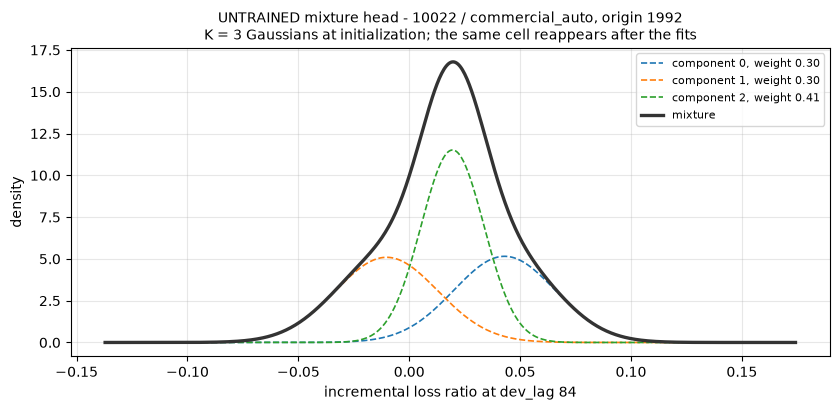

In [18]:
# The cell that gets revisited after training: the deepest cell on the scored diagonal whose
# dev step is not pinned. (A pinned dev has no trained head - the section right after the
# fits explains why the deepest cell of all always sits at one, hence its exclusion here.)
_cand = np.argwhere((nn_contract["cal_idx"] == SCORED_DIAG) & ~demo_pinned[0][None, :])
_pick = _cand[_cand[:, 1].argmax()]
DEMO_W, DEMO_D = int(_pick[0]), int(_pick[1])
DEMO_DEV_LAG = (DEMO_D + 1) * nn_contract["dev_grain_months"]
print(
    f"demo cell: {DEMO}, origin {_years[DEMO_W]}, dev_lag {DEMO_DEV_LAG} months "
    f"(grid position w={DEMO_W}, d={DEMO_D}, calendar diagonal {SCORED_DIAG})"
)


def mixture_components(log_pi, mu, sigma, dev, grid, mean0, std0):
    """The K weighted Gaussian densities on the LOSS-RATIO scale: (K, len(grid)).

    The head models the standardized ratio z, so each component's mean and scale are
    un-standardized with that dev step's statistics before being evaluated, and the
    density is divided by the standard deviation as the change of variable requires.
    """
    m = np.asarray(mu) * std0[dev] + mean0[dev]
    s = np.asarray(sigma) * std0[dev]
    w = np.exp(np.asarray(log_pi))
    z = (grid[None, :] - m[:, None]) / s[:, None]
    return w[:, None] * np.exp(-0.5 * z**2) / (s[:, None] * np.sqrt(2 * np.pi))


_lp = demo_log_pi[DEMO_CI, DEMO_W, DEMO_D].numpy()
_mu = demo_mu[DEMO_CI, DEMO_W, DEMO_D].numpy()
_sg = demo_sigma[DEMO_CI, DEMO_W, DEMO_D].numpy()
display(
    pd.DataFrame(
        {
            "component": range(demo_cfg.n_components),
            "weight": np.exp(_lp),
            "mean (loss ratio)": _mu * demo_std[0, DEMO_D] + demo_mean[0, DEMO_D],
            "sd (loss ratio)": _sg * demo_std[0, DEMO_D],
        }
    ).round(4)
)

grid_a = np.linspace(
    demo_mean[0, DEMO_D] - 5 * demo_std[0, DEMO_D],
    demo_mean[0, DEMO_D] + 5 * demo_std[0, DEMO_D],
    600,
)
comp_a = mixture_components(_lp, _mu, _sg, DEMO_D, grid_a, demo_mean[0], demo_std[0])
fig, ax = plt.subplots(figsize=(8.5, 4.2))
for k in range(comp_a.shape[0]):
    ax.plot(grid_a, comp_a[k], lw=1.2, ls="--", label=f"component {k}, weight {np.exp(_lp[k]):.2f}")
ax.plot(grid_a, comp_a.sum(axis=0), lw=2.4, color="#333333", label="mixture")
ax.set_xlabel(f"incremental loss ratio at dev_lag {DEMO_DEV_LAG}")
ax.set_ylabel("density")
ax.set_title(
    f"UNTRAINED mixture head - {DEMO[0]} / {DEMO[1]}, origin {_years[DEMO_W]}\n"
    f"K = {demo_cfg.n_components} Gaussians at initialization; the same cell reappears after "
    "the fits",
    fontsize=10,
)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Step 6: the training scheme

The scheme is where most of this entry's measured performance came from, and two of its
three pieces are shared by every neural entry in the gallery (`gallery/nn/_scheme.py`,
`gallery/nn/_training.py`) precisely so that a new entry cannot reimplement them slightly
wrong.

**Validation by calendar date, not by random cell.** A random hold-out would let the model
train on a cell and validate on its neighbour at the same evaluation date, which is not the
question a reserving model is asked. `splits` holds out the trailing observed calendar
diagonals of the training window instead, and they are excluded from every training context
*and* every training target.

**Per-development standardization, pinned.** Increments at 12 months and increments at 96
months differ by an order of magnitude, so the target is standardized within each
development step, from training-context cells wherever there are at least two of them. The
pinning rule in `norm_stats` is the change that mattered
most in this model's history. A development step with fewer than two context values - in
practice the deepest, whose only observations sit on the held-out diagonal - has its
standardized value **defined** as 0, with the mean taken from all observed cells at that step
and the standard deviation fixed at 1. Version 1 instead inherited an earlier step's
statistics, which denormalized tail cells at mid-development magnitudes and systematically
overstated fast-decaying tails; replacing that inheritance with pinning took the paid mean
error from +14% to +4% and the reported mean error from +148% to +1.7% in the milestone-3
retrospective. It is also the direct cause of the ELPD gap demonstrated immediately after
the fits: a pinned step has no trained head, so the entry refuses to report a density there.

**The one place the split is not airtight, stated because an earlier draft of this notebook
claimed it was.** At a *pinned* step the fallback mean is taken from `obs`, not from the
training context - read `norm_stats` above: `fallback = x[..., d][obs[..., d]]`. Those are
exactly the steps whose only observations sit on the held-out diagonal, so at those steps the
validation cells do reach the normalizer. What they reach is a *denormalization constant* and
not a trained parameter: the standardized value there is defined as 0 whatever the mean is,
and the step has no trained head to score with. The rollout does read that mean, so this is a
real if narrow dependence rather than none at all, and calling the split fully independent
would be an overstatement.


In [19]:
show_source(splits)
print("\n" + "=" * 96 + "\n")
show_source(norm_stats)

def splits(
    obs_mask: np.ndarray, cal_idx: np.ndarray, val_diagonals: int
) -> tuple[np.ndarray, np.ndarray, int]:
    """Carve the eval_date validation split out of the *training window*.

    Returns (context_eligible, val_target, val_cutoff): the trailing
    ``val_diagonals`` observed calendar diagonals become the validation
    targets for early stopping and are excluded from every training context
    and every training target - validating by calendar time (eval_date), the
    way the model is actually used at prediction, rather than by a random cell
    split. ``val_cutoff`` is the newest diagonal training may condition on."""
    c_max = int(cal_idx[obs_mask.any(axis=0)].max())
    val_cutoff = c_max - val_diagonals
    if val_cutoff < 2:
        raise ValueError(
            f"latest observed diagonal is {c_max}; need at least {2 + val_diagonals} "
            "diagonals to hold one out for validation and still train"
        )
    context_eligible = obs_mask & (cal_idx <=

In [20]:
print(f"deepest observed calendar diagonal on this panel: {demo_cutoff + demo_cfg.val_diagonals}")
print(f"val_cutoff, the newest diagonal training may condition on: {demo_cutoff}")
print(f"training-context cells {int(demo_ctx.sum()):,} | validation cells {int(demo_val.sum()):,}")
print()
display(
    pd.DataFrame(
        {
            "dev_lag": _devs,
            "context cells": [int(demo_ctx[:, :, d].sum()) for d in range(n_d)],
            "mean ratio": demo_mean[0],
            "sd ratio": demo_std[0],
            "pinned": demo_pinned[0],
        }
    ).round(5)
)
print(
    "The pinned row is the deepest development step. Its only observations sit on the "
    "held-out\nvalidation diagonal, so no training-context value reaches the normalizer, "
    "the head there is\nuntrained, sd is fixed at 1 and the standardized value is defined "
    "as 0 by the rule above."
)

deepest observed calendar diagonal on this panel: 8
val_cutoff, the newest diagonal training may condition on: 7
training-context cells 700 | validation cells 200



,dev_lag,context cells,mean ratio,sd ratio,pinned
0,12,175,0.19279,0.09674,False
1,24,150,0.17970,0.06523,False
2,36,125,0.11968,0.05518,False
3,48,100,0.08530,0.04918,False
4,60,75,0.05072,0.04129,False
5,72,50,0.03776,0.03830,False
6,84,25,0.01851,0.03113,False
7,96,0,0.00829,1.00000,True


The pinned row is the deepest development step. Its only observations sit on the held-out
validation diagonal, so no training-context value reaches the normalizer, the head there is
untrained, sd is fixed at 1 and the standardized value is defined as 0 by the rule above.


**Calendar-cutoff augmentation.** The third piece lives in the shared training loop. Each
epoch, each cohort is handed a *fake* valuation date drawn uniformly from inside the training
window: the network conditions on the cells on or before that diagonal and is scored on the
observed cells after it. One triangle therefore becomes several distinct "predict the next
diagonals" tasks, which is the main small-data multiplier - and it is what supervises the
distance-past-cutoff embedding at every distance the rollout will later ask for.

In [21]:
show_source(train_ensemble, first="CALENDAR-CUTOFF AUGMENTATION", last="n_batches += 1")

# train_ensemble, lines 69-85 of 112

                # CALENDAR-CUTOFF AUGMENTATION: draw a fake as_of diagonal per
                # cohort; the entry conditions on cells on/before it and scores
                # the observed training cells strictly after it. Each triangle
                # yields many "predict the next diagonals" tasks per epoch -
                # the main small-data multiplier.
                cutoffs = torch.tensor(
                    rng.integers(min_cutoff, val_cutoff, size=len(idx)), device=device
                )  # (B,) 1-based conditioning diagonal per cohort
                loss = train_loss(model, idx, cutoffs)
                if loss is None:
                    continue  # this batch's cutoffs left nothing to score
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
                opt.step()
                epoch_loss += float(loss.detach())
             

In [22]:
# What one cohort's training example looks like at each of the drawn cutoffs: the context
# grows, the scored set shrinks, and the same triangle is several tasks.
_min_cutoff = max(1, min(demo_cfg.min_cutoff, demo_cutoff - 1))
print(f"cutoffs are drawn uniformly from [{_min_cutoff}, {demo_cutoff})")
display(
    pd.DataFrame(
        [
            {
                "cutoff diagonal": cutoff,
                "context cells": int(ctx_c.sum()),
                "scored cells": int(tgt_c.sum()),
                "deepest distance past cutoff": int(
                    (nn_contract["cal_idx"][tgt_c] - cutoff).max() if tgt_c.any() else 0
                ),
            }
            for cutoff in range(_min_cutoff, demo_cutoff)
            for ctx_c, tgt_c in [cutoff_masks(demo_ctx[DEMO_CI], nn_contract["cal_idx"], cutoff)]
        ]
    )
)
print(
    f"One cutoff is drawn per cohort per epoch out of {demo_cutoff - _min_cutoff} possible "
    f"ones, over up\nto {demo_cfg.max_epochs} epochs, so each cohort is trained at every "
    "cutoff many times. The last column\nis the range of relative-calendar positions this "
    "supervises: at prediction time only distance 1\nis ever consumed, because both the "
    "held-out scorer and the rollout re-encode at every diagonal."
)

cutoffs are drawn uniformly from [4, 7)


,cutoff diagonal,context cells,scored cells,deepest distance past cutoff
0,4,10,18,3
1,5,15,13,2
2,6,21,7,1


One cutoff is drawn per cohort per epoch out of 3 possible ones, over up
to 120 epochs, so each cohort is trained at every cutoff many times. The last column
is the range of relative-calendar positions this supervises: at prediction time only distance 1
is ever consumed, because both the held-out scorer and the rollout re-encode at every diagonal.


### The whole flow

One figure for the six steps: the contract, the tokens, the embeddings, the attention, the
mixture head, and - after training - the autoregressive rollout that turns per-cell mixtures
into ultimates.

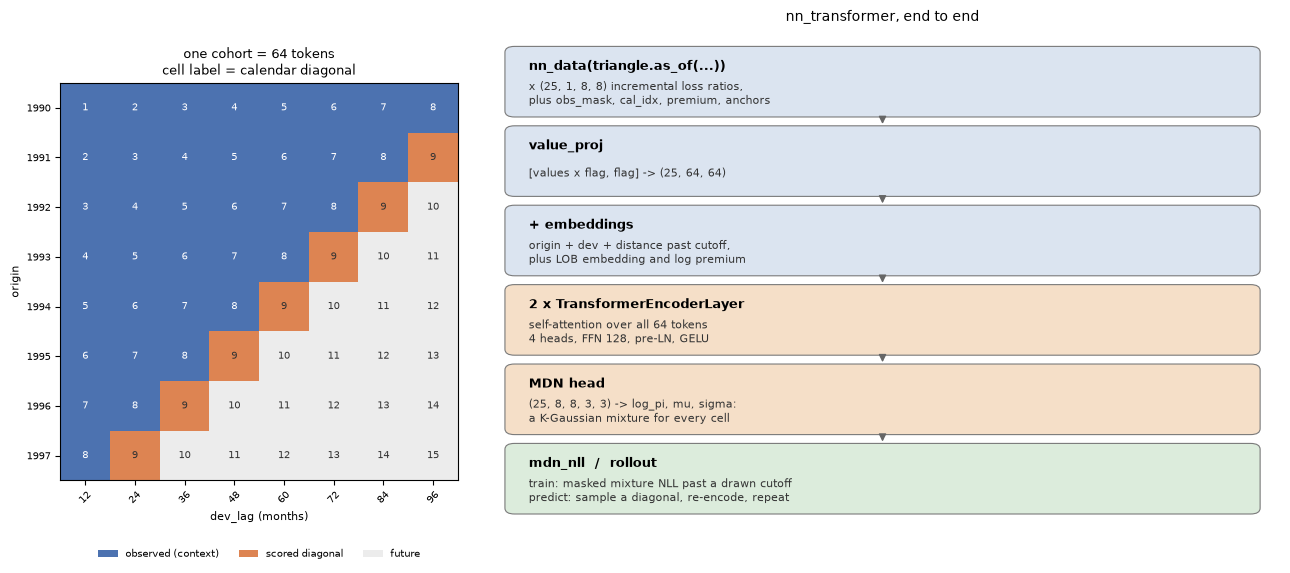

In [23]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, (axg, axf) = plt.subplots(1, 2, figsize=(13, 5.6), gridspec_kw={"width_ratios": [1, 2.0]})

# left: this cohort's grid, coloured by the role each cell plays
codes = np.where(DEMO_OBS, 0, np.where(nn_contract["cal_idx"] == SCORED_DIAG, 1, 2))
axg.imshow(codes, cmap=ListedColormap(["#4c72b0", "#dd8452", "#ececec"]), vmin=0, vmax=2)
for w in range(n_w):
    for d in range(n_d):
        axg.text(
            d,
            w,
            nn_contract["cal_idx"][w, d],
            ha="center",
            va="center",
            fontsize=7,
            color="white" if codes[w, d] == 0 else "#333333",
        )
axg.set_xticks(range(n_d), _devs, fontsize=7, rotation=45)
axg.set_yticks(range(n_w), _years, fontsize=7)
axg.set_xlabel("dev_lag (months)", fontsize=8)
axg.set_ylabel("origin", fontsize=8)
axg.set_title(f"one cohort = {n_w * n_d} tokens\ncell label = calendar diagonal", fontsize=9)
axg.legend(
    handles=[
        Patch(facecolor="#4c72b0", label="observed (context)"),
        Patch(facecolor="#dd8452", label="scored diagonal"),
        Patch(facecolor="#ececec", label="future"),
    ],
    fontsize=7,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
)

# right: the flow, one box per step
axf.set_xlim(0, 10)
axf.set_ylim(-0.3, 10)
axf.axis("off")
steps = [
    (
        "nn_data(triangle.as_of(...))",
        f"x ({n_c}, {n_f}, {n_w}, {n_d}) incremental loss ratios,\n"
        "plus obs_mask, cal_idx, premium, anchors",
        "#dbe4f0",
    ),
    (
        "value_proj",
        f"[values x flag, flag] -> ({n_c}, {n_w * n_d}, {demo_cfg.d_model})",
        "#dbe4f0",
    ),
    (
        "+ embeddings",
        "origin + dev + distance past cutoff,\nplus LOB embedding and log premium",
        "#dbe4f0",
    ),
    (
        f"{demo_cfg.n_layers} x TransformerEncoderLayer",
        f"self-attention over all {n_w * n_d} tokens\n"
        f"{demo_cfg.n_heads} heads, FFN {demo_cfg.ffn_dim}, pre-LN, GELU",
        "#f5dfc8",
    ),
    (
        "MDN head",
        f"({n_c}, {n_w}, {n_d}, 3, {demo_cfg.n_components}) -> log_pi, mu, sigma:\n"
        "a K-Gaussian mixture for every cell",
        "#f5dfc8",
    ),
    (
        "mdn_nll  /  rollout",
        "train: masked mixture NLL past a drawn cutoff\n"
        "predict: sample a diagonal, re-encode, repeat",
        "#dcecdc",
    ),
]
box_h, gap = 1.34, 0.28
for i, (title, body, colour) in enumerate(steps):
    top = 9.6 - i * (box_h + gap)
    axf.add_patch(
        FancyBboxPatch(
            (0.3, top - box_h),
            9.4,
            box_h,
            boxstyle="round,pad=0.05,rounding_size=0.12",
            facecolor=colour,
            edgecolor="#7a7a7a",
            linewidth=0.8,
        )
    )
    axf.text(0.55, top - 0.36, title, fontsize=9.5, fontweight="bold", va="center")
    axf.text(0.55, top - 0.92, body, fontsize=8, va="center", color="#333333")
    if i:
        axf.add_patch(
            FancyArrowPatch(
                (5.0, top + gap),
                (5.0, top + 0.03),
                arrowstyle="-|>",
                mutation_scale=11,
                color="#666666",
                linewidth=1.0,
            )
        )
axf.set_title("nn_transformer, end to end", fontsize=10)
fig.tight_layout()
plt.show()

In [24]:
from ibnr.gallery.nn.deeptriangle import DeepTriangleConfig
from ibnr.gallery.nn.mdn import MDNConfig
from ibnr.gallery.nn.resnet import ResNetConfig
from ibnr.gallery.nn.transformer import TransformerConfig

# One pooled fit per entry over the WHOLE panel triangle, then 25 cohort
# forecasts off it. The cost therefore amortizes, and the clustering unit for
# any paired test on these rows is the FIT (the whole panel), not the cohort.
NN_ENTRIES = {
    "nn_transformer": TransformerConfig,
    "mdn": MDNConfig,
    "resnet": ResNetConfig,
    "deeptriangle": DeepTriangleConfig,
}
nn_fits = {}
for name, ConfigCls in NN_ENTRIES.items():
    t0 = time.perf_counter()
    entry = gallery.fit(
        name, tri, loss_field=FIELD, as_of=AS_OF, seed=SEED_FIT, config=ConfigCls(**NN_CONFIG)
    )
    t_fit = time.perf_counter() - t0
    for key in COHORTS:
        forecasts.append(forecast_for(name, entry, key))
        record_point(name, entry, key)
    fit_seconds[name] = round(time.perf_counter() - t0, 1)
    nn_fits[name] = entry
    print(
        f"{name:22s} {fit_seconds[name]:7.1f}s  (pooled fit {t_fit:.1f}s + "
        f"{fit_seconds[name] - t_fit:.1f}s scoring 25 cohorts)",
        flush=True,
    )

nn_transformer            38.4s  (pooled fit 27.9s + 10.5s scoring 25 cohorts)


mdn                       12.3s  (pooled fit 8.3s + 4.0s scoring 25 cohorts)


resnet                    24.7s  (pooled fit 19.3s + 5.4s scoring 25 cohorts)


deeptriangle              32.8s  (pooled fit 24.8s + 8.0s scoring 25 cohorts)


### The deepest scored cell is the fit's own frontier

All four NN entries refused a density on every cohort just now, and the reason is
structural rather than a fact about this panel.

The scored diagonal is the one immediately after the fit's training window, so its
deepest cell sits at exactly the deepest development lag the fit ever saw. Per cohort
that lag is reached by a single accident year on a single calendar diagonal - the latest
one - and the NN training scheme holds the latest diagonals out as the validation split
(`gallery/nn/_scheme.py::splits`, an eval_date split rather than a random one). So the
pooled per-development normalizer has **no** training context at that step, the step is
*pinned*, and `log_lik_at` refuses rather than scoring against an untrained head
(`norm_stats`; the v2 fix the model cards describe).

Moving the window does not escape it - the frontier moves with the window. The earlier
run avoided it only by scoring a diagonal two development steps shallower than the one
its fits were trained for, which is precisely the provenance mismatch this version
removes. The honest consequence is that the four NN entries have **no ELPD column on a
consistent panel**, and their ELPD rows in the earlier run should be read as an artefact
of that mismatch.

The cell below shows the three parts of that claim from this run: the refusal names the
pinned development step; the identical fits score a probe diagonal that stops one step
short of the frontier; and `predict_at` works at the pinned step throughout, which is
why the NN entries keep every CRPS cell they offer.


In [25]:
# 1. the refusal, read off this run rather than re-derived.
_nn_refused = [r for r in refusals if r["model"] in nn_fits and r["axis"] == "density"]
print(
    f"NN density refusals this run: {len(_nn_refused)} of {len(nn_fits) * len(COHORTS)} "
    f"(entry, cohort) pairs - i.e. every one"
)
print("  ", _nn_refused[0]["model"], "->", _nn_refused[0]["error"][:230])

# 2. a PROBE, not a study object: the same cohort's diagonal one accident year
#    shallower, so its deepest cell is a development step INSIDE the fits'
#    frontier. The fitted entries are untouched; only the cells change.
_s0 = sub[COHORTS[0]]
_probe = next_diagonal(
    _s0.filter(_s0.expr.origin_period.isin(ORIGINS[1:])),
    as_of=AS_OF,
    fields=[FIELD, "reported_loss"],
    premium_field=PREMIUM_FIELD,
)
_pf = cells[COHORTS[0]].frame
_panel_devs = sorted(_pf.loc[_pf["field"] == FIELD, "dev_lag"])
_probe_devs = sorted(_probe.frame.loc[_probe.frame["field"] == FIELD, "dev_lag"])
print(f"\n{COHORTS[0]} panel cells: dev_lags {_panel_devs}")
print(f"{' ' * len(str(COHORTS[0]))} probe cells: dev_lags {_probe_devs}")

# 3. all four, because the claim is about the whole NN family and the four heads
#    do not share a density implementation.
for _name, _fit in nn_fits.items():
    try:
        _ll = _fit.log_lik_at(_probe, field=FIELD)
        _verdict = f"probe density SCORED {_ll.shape}"
    except Exception as exc:
        _verdict = f"probe density ALSO refused: {type(exc).__name__}: {exc}"[:120]
    _draws = _fit.predict_at(cells[COHORTS[0]], field=FIELD, seed=SEED_DRAW)
    print(f"\n{_name}: {_verdict}")
    print(f"{' ' * len(_name)}  draws at the pinned frontier are fine: {_draws.shape}")

NN density refusals this run: 100 of 100 (entry, cohort) pairs - i.e. every one
   nn_transformer -> ValueError('1 cell(s) sit at pinned dev step(s) [8]: fewer than two training-context values reached the per-dev normalizer there, so the MDN head is untrained and its scale is degenerate. nn_transform



('10022', 'commercial_auto') panel cells: dev_lags [24, 36, 48, 60, 72, 84, 96]
                             probe cells: dev_lags [24, 36, 48, 60, 72, 84]

nn_transformer: probe density SCORED (5, 6)
                draws at the pinned frontier are fine: (500, 7)

mdn: probe density SCORED (5, 6)
     draws at the pinned frontier are fine: (500, 7)

resnet: probe density SCORED (5, 6)
        draws at the pinned frontier are fine: (500, 7)

deeptriangle: probe density SCORED (5, 6)
              draws at the pinned frontier are fine: (500, 7)


### The trained head, and the same cell again

Before the fits, the mixture at this cohort's deepest scorable held-out cell was whatever
the initialization happened to produce. The fits have now run, so the same cell can be asked
again - and this time it is a real predictive distribution, the kind of density an ELPD is
made of.

The cells used are the `_probe` set from just above rather than the panel's own, for the
reason that section demonstrated: the panel's deepest cell sits at a pinned development step
and the entry refuses a density there, which is why these four entries have no ELPD column
on this board. Every other cell of the diagonal, including this one, is scored normally.

Two things are visible in the plot below that the untrained version could not show. The five
faint curves are the five **ensemble members**: five networks trained from different seeds on
the same data, which is where this entry's epistemic spread comes from. `log_lik_at` returns
one row per member, because for a deep ensemble the members *are* the draw axis, and the
leaderboard's `logmeanexp` over that axis is the ensemble-average predictive density - the
bold curve, and the analogue of averaging a posterior's per-draw likelihoods.

The arithmetic is checked rather than asserted: the density is rebuilt below from the raw
mixture parameters and compared member by member against what the public `log_lik_at`
returns for the same cell. That also exercises the measure carry - the head is a density of
the *standardized ratio*, the entry folds in the standardization Jacobian to reach the *loss
ratio*, and the base class subtracts `log premium` to reach a density on dollars.

In [26]:
from scipy.special import logsumexp

from ibnr.kernels.holdout import index_into

nn_entry = nn_fits["nn_transformer"]
demo_seg = {"company_code": DEMO[0], "line_of_business": DEMO[1]}
demo_view = nn_entry.at_cohort(demo_seg)

# the fitted entry's own contract and normalizer must be the ones Part A rebuilt
assert np.allclose(nn_entry.norm_["mean"], demo_mean)
assert np.allclose(nn_entry.norm_["std"], demo_std)
mean0, std0 = nn_entry.norm_["mean"][0], nn_entry.norm_["std"][0]

# `_probe` (built two cells up) is this cohort's held-out diagonal minus its pinned deepest
# cell, so every one of its cells is density-scorable by all four NN entries.
demo_idx = index_into(_probe, demo_view.contract_, field=FIELD)
j = int(np.argmax((demo_idx.w == DEMO_W + 1) & (demo_idx.d == DEMO_D + 1)))
assert (demo_idx.w[j], demo_idx.d[j]) == (DEMO_W + 1, DEMO_D + 1)

fit_log_pi, fit_mu, fit_sigma = nn_entry._heldout_mixture(demo_view.cohort, demo_idx)
n_members = fit_log_pi.shape[0]
demo_premium = float(nn_entry.contract_["premium"][demo_view.cohort][DEMO_W])
outcome_ratio = float((demo_idx.value[j] - demo_idx.prev_value[j]) / demo_premium)

print(f"cohort {DEMO}, origin {_years[DEMO_W]}, dev_lag {DEMO_DEV_LAG} months")
print(f"ensemble members (the density's draw axis): {n_members}")
print(
    f"premium {demo_premium:,.0f} | cumulative {demo_idx.prev_value[j]:,.0f} -> "
    f"{demo_idx.value[j]:,.0f}"
)
print(f"realized incremental loss ratio at this cell: {outcome_ratio:.5f}")

display(
    pd.DataFrame(
        [
            {
                "member": m,
                "component": k,
                "weight": float(np.exp(fit_log_pi[m, j, k])),
                "mean (loss ratio)": float(fit_mu[m, j, k] * std0[DEMO_D] + mean0[DEMO_D]),
                "sd (loss ratio)": float(fit_sigma[m, j, k] * std0[DEMO_D]),
            }
            for m in range(n_members)
            for k in range(fit_log_pi.shape[2])
        ]
    ).round(5)
)

cohort ('10022', 'commercial_auto'), origin 1992, dev_lag 84 months
ensemble members (the density's draw axis): 5
premium 1,281 | cumulative 623 -> 626
realized incremental loss ratio at this cell: 0.00234


,member,component,weight,mean (loss ratio),sd (loss ratio)
0,0,0,0.25530,0.05833,0.05080
1,0,1,0.23557,-0.00033,0.02104
2,0,2,0.50913,-0.00138,0.00670
3,1,0,0.38688,-0.01291,0.01319
4,1,1,0.34395,0.01298,0.01883
5,1,2,0.26917,0.05104,0.04363
6,2,0,0.29932,0.00463,0.01867
7,2,1,0.27571,0.00709,0.02308
8,2,2,0.42498,0.02654,0.02764
9,3,0,0.63735,0.00425,0.01762


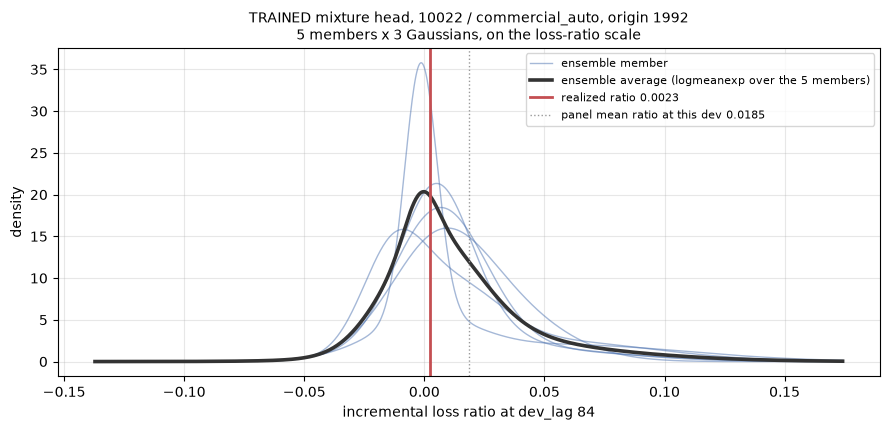

per-member log density on the amount scale
  log_lik_at : [-3.704801 -4.550701 -4.434504 -4.10982  -4.265906]
  rebuilt    : [-3.704801 -4.550701 -4.434504 -4.10982  -4.265906]
  max abs difference: 1.0297970742811913e-07

ensemble-average log density, the quantity a pointwise ELPD sums: -4.1672 nats


In [27]:
grid_b = np.linspace(mean0[DEMO_D] - 5 * std0[DEMO_D], mean0[DEMO_D] + 5 * std0[DEMO_D], 800)
member_pdf = np.stack(
    [
        mixture_components(
            fit_log_pi[m, j], fit_mu[m, j], fit_sigma[m, j], DEMO_D, grid_b, mean0, std0
        ).sum(axis=0)
        for m in range(n_members)
    ]
)
ensemble_pdf = member_pdf.mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 4.4))
for m in range(n_members):
    ax.plot(
        grid_b,
        member_pdf[m],
        lw=1.0,
        color="#4c72b0",
        alpha=0.5,
        label="ensemble member" if m == 0 else "_nolegend_",
    )
ax.plot(
    grid_b,
    ensemble_pdf,
    lw=2.6,
    color="#333333",
    label="ensemble average (logmeanexp over the 5 members)",
)
ax.axvline(outcome_ratio, color="#c44e52", lw=2.0, label=f"realized ratio {outcome_ratio:.4f}")
ax.axvline(
    mean0[DEMO_D],
    color="#999999",
    lw=1.0,
    ls=":",
    label=f"panel mean ratio at this dev {mean0[DEMO_D]:.4f}",
)
ax.set_xlabel(f"incremental loss ratio at dev_lag {DEMO_DEV_LAG}")
ax.set_ylabel("density")
ax.set_title(
    f"TRAINED mixture head, {DEMO[0]} / {DEMO[1]}, origin {_years[DEMO_W]}\n"
    f"{n_members} members x {demo_cfg.n_components} Gaussians, on the loss-ratio scale",
    fontsize=10,
)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# The published number, and the same number rebuilt by hand from the mixture parameters.
api = demo_view.log_lik_at(_probe, field=FIELD)  # (members, cells), Lebesgue on amount
by_hand = np.array(
    [
        np.log(
            mixture_components(
                fit_log_pi[m, j],
                fit_mu[m, j],
                fit_sigma[m, j],
                DEMO_D,
                np.array([outcome_ratio]),
                mean0,
                std0,
            ).sum()
        )
        - np.log(demo_premium)
        for m in range(n_members)
    ]
)
print("per-member log density on the amount scale")
print("  log_lik_at :", np.round(api[:, j], 6))
print("  rebuilt    :", np.round(by_hand, 6))
print("  max abs difference:", float(np.max(np.abs(api[:, j] - by_hand))))
print()
print(
    "ensemble-average log density, the quantity a pointwise ELPD sums: "
    f"{float(logsumexp(api[:, j]) - np.log(n_members)):.4f} nats"
)

### Prediction: the autoregressive rollout

Scoring one held-out diagonal needs a single forward pass, because that diagonal sits one
step past everything the cohort has observed. An **ultimate** is different: it is the sum of
every remaining future cell, seven calendar diagonals deep on this panel, and the network
has never been trained to jump that far.

So `predict()` does not jump. It walks, one calendar diagonal at a time - the transformer's
analogue of the chain-ladder recursion. Sample every future cell on the next diagonal from
its mixture, write the samples into the grid as if they were data, promote them to context,
re-encode the whole grid, and step to the next diagonal.

Re-encoding after every diagonal buys two things. The predicted diagonal is always at
**distance 1** past the context boundary, which is the relative-calendar position the cutoff
augmentation supervised most heavily - so inference never asks the network a question it was
not trained on. And the draws come out **jointly coherent** across a cohort's cells rather
than only marginally right, because each sampled cell conditions on the cells sampled before
it through the shared encoded context. That is what makes a sum over cells - an ultimate, or
the cohort-total PIT tested later in this notebook - a legitimate object rather than a sum of
unrelated marginals.

In [28]:
show_source(type(nn_entry)._rollout, first="# future cells: at/beyond", last="cal_levels = sorted(")
print("\n" + "=" * 100 + "\n")
show_source(type(nn_entry)._rollout, first="with torch.no_grad():", last="ctx = ctx | cells")
print("\n" + "=" * 100 + "\n")
show_source(
    type(nn_entry)._rollout, first="# unstandardize the target", last='ults = c["latest_cum"]'
)

# NNTransformer._rollout, lines 21-28 of 104

        # future cells: at/beyond each origin's latest observed dev (its anchor)
        # - everything to be predicted. latest_dev is 1-based, d_grid 0-based,
        # so `>=` includes the first unobserved dev.
        d_grid = np.arange(n_d)[None, None, :]
        future = d_grid >= c["latest_dev"][:, :, None]  # (n_c, n_w, n_d) bool
        # calendar diagonals that contain any future cell, in ascending order -
        # the rollout advances through these one at a time.
        cal_levels = sorted(np.unique(c["cal_idx"][future.any(axis=0)]))


# NNTransformer._rollout, lines 74-94 of 104

                with torch.no_grad():
                    for lv in cal_levels:
                        # future cells sitting exactly on this diagonal
                        cells = futb & (cal_t[None] == lv)  # (chunk*n_c, n_w, n_d)
                        if not bool(cells.any()):
                            continue
                        # conte

In [29]:
# The rollout's own numbers for this fit, re-derived from the fitted contract.
_c = nn_entry.contract_
_future = np.arange(_c["n_d"])[None, None, :] >= _c["latest_dev"][:, :, None]
_levels = [int(v) for v in sorted(np.unique(_c["cal_idx"][_future.any(axis=0)]))]
_n_members = len(nn_entry.models_)
_split = [nn_entry.config_.n_draws // _n_members] * _n_members
for _i in range(nn_entry.config_.n_draws % _n_members):
    _split[_i] += 1

print(f"future cells to fill, over the whole panel: {int(_future.sum()):,}")
print(f"calendar diagonals stepped through: {_levels}")
print(f"forward passes per draw: {len(_levels)} (one per diagonal, re-encoding each time)")
print(f"ensemble members: {_n_members}, draws split as {_split} -> {sum(_split)} pooled draws")
print()
print("ultimate = latest_cum + premium x (sum of sampled future incremental ratios)")
_pred = nn_entry.predict(segment=demo_seg, seed=SEED_DRAW)
_real = nn_entry.realized_ultimates(sub[DEMO], segment=demo_seg)
_tot = _pred.targets["label"].astype(str).tolist().index("total")
print(
    f"{DEMO}: predicted total ultimate {_pred.mean()[_tot]:,.0f} "
    f"(sd {_pred.std()[_tot]:,.0f}) vs realized {float(_real[_tot]):,.0f}"
)

future cells to fill, over the whole panel: 700
calendar diagonals stepped through: [9, 10, 11, 12, 13, 14, 15]
forward passes per draw: 7 (one per diagonal, re-encoding each time)
ensemble members: 5, draws split as [100, 100, 100, 100, 100] -> 500 pooled draws

ultimate = latest_cum + premium x (sum of sampled future incremental ratios)
('10022', 'commercial_auto'): predicted total ultimate 6,046 (sd 342) vs realized 5,400


In [30]:
panel = align_panel(forecasts, units=tri.meta.units)
print(repr(panel))
print()
print(
    f"ELPD panel: {panel.n_cells_for('elpd'):4d} cells over "
    f"{panel.n_cohorts_for('elpd')} cohorts | members {list(panel.elpd_members)}"
)
print(f"            fingerprint {panel.elpd_fingerprint}")
print(
    f"CRPS panel: {panel.n_cells_for('crps'):4d} cells over "
    f"{panel.n_cohorts_for('crps')} cohorts | members {list(panel.crps_members)}"
)
print(f"            fingerprint {panel.crps_fingerprint}")
print(f"union of the two panels: {panel.n_cells} cells")

ForecastPanel(paid_loss@1997 @ 1997-12-31, 12 models, 24 cohorts | elpd: 126 cells over ['compartmental', 'guszcza_growth_curve', 'meyers_ccl', 'meyers_csr'] | crps: 168 cells over ['clark', 'clark_growth_curve', 'compartmental', 'deeptriangle', 'england_verrall_odp', 'guszcza_growth_curve', 'mack', 'mdn', 'meyers_ccl', 'meyers_csr', 'nn_transformer', 'resnet'] | dropped=56)

ELPD panel:  126 cells over 18 cohorts | members ['compartmental', 'guszcza_growth_curve', 'meyers_ccl', 'meyers_csr']
            fingerprint 0bd1e6212c5c56f2
CRPS panel:  168 cells over 24 cohorts | members ['clark', 'clark_growth_curve', 'compartmental', 'deeptriangle', 'england_verrall_odp', 'guszcza_growth_curve', 'mack', 'mdn', 'meyers_ccl', 'meyers_csr', 'nn_transformer', 'resnet']
            fingerprint 468d769145503ba4
union of the two panels: 168 cells


## How to read the board

* **ELPD is higher-is-better, CRPS is lower-is-better.** They point in opposite
  directions, which is why `SCORE_DIRECTION` is machine-readable and why `leaderboard()`
  has **no default sort and no `sort_by=`**: an average-rank column across two columns
  running opposite ways is nonsense, and the board refuses to invite one.
* **A missing score is `pd.NA`, never `0.0`.** On this board a pointwise ELPD is about
  -9 nats, so imputing 0 would credit a model that was never scored with more than the
  entire plausible gap between two real models - and 0.0 is simultaneously the best ELPD
  and the best CRPS there is. Every total is reduced in Python from the model's own
  array, because `groupby().sum()` over an all-missing group returns 0.0 in pandas.
* **The two columns can rest on different cells.** Each score's panel is the
  intersection over the models eligible for *that* score, so the board has
  `n_cells_elpd` and `n_cells_crps` and never a bare `n_cells`. Each column carries its
  own member list and its own fingerprint, stamped on every row: the number carries the
  set that produced it.
* **`elpd_status` says which kind of N/A this is.** `na: no_predictive_density` is
  permanent and about the entry (the ODP quasi-likelihood, the Mack bootstrap, the Clark
  MLE). `na: no_scored_cohorts` is this run: the four NN entries offered a density on no
  cohort at all, because every cohort's deepest scored cell is a pinned development step
  - see the section above. Both read as N/A on the board and they mean different things.
* **`n_cells_zero_density`** counts cells where every posterior draw gave the outcome
  zero density. Those propagate as `-inf` rather than being dropped - a model that
  assigned zero probability to something that happened should rank last, not escape.
* **`min_ess_kish`** is the effective number of draws behind the worst cell's density,
  and **`n_draws_density_min`** the raw draw count. It is what separates a lead from a
  tie, and here it dissolves one: `compartmental` tops the ELPD column by about 0.35
  nats per cell over `meyers_csr`, and `min_ess_kish` says its worst cell's density
  rests on **2** effective draws out of 4,000, against roughly 3,100 out of 10,000 for
  `meyers_csr` and `meyers_ccl`. Three orders of magnitude fewer. Read the top of that
  column as "not separated at this budget" rather than as a ranking.


In [31]:
board = gallery.leaderboard(panel)
view = board[
    [
        "model",
        "n_cohorts",
        "n_cells_elpd",
        "elpd",
        "elpd_per_cell",
        "elpd_status",
        "n_cells_zero_density",
        "min_ess_kish",
        "n_draws_density_min",
        "n_cells_crps",
        "crps",
        "crps_per_cell",
        "n_draws_sample_min",
    ]
].copy()
print("SCORE_DIRECTION:", SCORE_DIRECTION)
view.sort_values("crps_per_cell").round(3)

SCORE_DIRECTION: {'elpd': 'higher_is_better', 'elpd_per_cell': 'higher_is_better', 'crps': 'lower_is_better', 'crps_per_cell': 'lower_is_better'}


,model,n_cohorts,n_cells_elpd,elpd,elpd_per_cell,elpd_status,n_cells_zero_density,min_ess_kish,n_draws_density_min,n_cells_crps,crps,crps_per_cell,n_draws_sample_min
6,mack,24,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,<NA>,168,560523.035,3336.447,10000
4,england_verrall_odp,24,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,<NA>,168,628358.518,3740.229,10000
2,compartmental,24,126,-1125.788,-8.935,scored,0,1.982,4000,168,637264.285,3793.24,4000
9,meyers_csr,24,126,-1169.875,-9.285,scored,0,3096.037,10000,168,640914.816,3814.969,10000
3,deeptriangle,24,126,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,<NA>,168,740571.531,4408.164,500
11,resnet,24,126,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,<NA>,168,768079.3,4571.901,500
7,mdn,24,126,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,<NA>,168,921318.384,5484.038,500
8,meyers_ccl,24,126,-1176.555,-9.338,scored,0,3079.84,10000,168,955455.801,5687.237,10000
1,clark_growth_curve,24,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,<NA>,168,1191250.284,7090.775,10000
0,clark,24,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,<NA>,168,1195338.964,7115.113,10000


In [32]:
# The full board, including the member lists and fingerprints every published
# number has to carry.
board

,task,as_of,model,n_cohorts,elpd_members,elpd_fingerprint,n_cells_elpd,elpd,elpd_per_cell,elpd_status,n_cells_zero_density,min_ess_kish,crps_members,crps_fingerprint,n_cells_crps,crps,crps_per_cell,crps_status,n_draws_density_min,n_draws_sample_min,n_cells_elpd_own,n_cells_elpd_dropped,n_cells_crps_own,n_cells_crps_dropped
0,paid_loss@1997,1997-12-31,clark,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,1195338.964447,7115.112884,scored,<NA>,10000,0,0,168,0
1,paid_loss@1997,1997-12-31,clark_growth_curve,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,1191250.283609,7090.775498,scored,<NA>,10000,0,0,175,7
2,paid_loss@1997,1997-12-31,compartmental,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,-1125.788246,-8.934827,scored,0,1.981614,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,637264.284861,3793.239791,scored,4000,4000,126,0,175,7
3,paid_loss@1997,1997-12-31,deeptriangle,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,740571.530864,4408.163874,scored,<NA>,500,0,0,175,7
4,paid_loss@1997,1997-12-31,england_verrall_odp,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,628358.517814,3740.229273,scored,<NA>,10000,0,0,175,7
5,paid_loss@1997,1997-12-31,guszcza_growth_curve,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,-1200.448089,-9.527366,scored,0,319.303412,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,1961591.592472,11676.140431,scored,4000,4000,175,49,175,7
6,paid_loss@1997,1997-12-31,mack,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_predictive_density,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,560523.035198,3336.446638,scored,<NA>,10000,0,0,175,7
7,paid_loss@1997,1997-12-31,mdn,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,<NA>,<NA>,na: no_scored_cohorts,<NA>,<NA>,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,921318.384146,5484.038001,scored,<NA>,500,0,0,175,7
8,paid_loss@1997,1997-12-31,meyers_ccl,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,-1176.555194,-9.33774,scored,0,3079.840057,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,955455.801126,5687.236911,scored,10000,10000,175,49,175,7
9,paid_loss@1997,1997-12-31,meyers_csr,24,"compartmental,guszcza_growth_curve,meyers_ccl,...",0bd1e6212c5c56f2,126,-1169.874777,-9.28472,scored,0,3096.037004,"clark,clark_growth_curve,compartmental,deeptri...",468d769145503ba4,168,640914.815561,3814.96914,scored,10000,10000,175,49,175,7


## What the panel cost

`panel.dropped` names every cell a member offered and the panel could not use, and which
member lacked it. `panel.absences` is the census behind every N/A. `panel.coverage` says
what each model offered and what survived. This is the milestone-6 design working: a
member that refuses one cohort removes that cohort from **that score's** panel for every
other member of that score - and from that score only.

In [33]:
print("dropped cells:", len(panel.dropped))
if len(panel.dropped):
    display(panel.dropped.head(12))
    print("\ndropped by score:", panel.dropped["score"].value_counts().to_dict())

# Summarised, not listed: the NN density refusals alone are one per (entry, cohort),
# and a hundred near-identical lines would bury the two that are not.
print("\nrun-level refusals recorded by the helper:", len(refusals))
_ref = pd.DataFrame(refusals)
if len(_ref):
    _ref["error (truncated)"] = _ref["error"].str.slice(0, 70)
    display(
        _ref.groupby(["model", "axis", "error (truncated)"], as_index=False)
        .agg(cohorts=("cohort", "nunique"))
        .sort_values(["model", "axis"])
        .reset_index(drop=True)
    )
display(panel.coverage)
display(
    panel.absences.groupby(["model", "axis", "reason", "scope"], as_index=False).agg(
        cohorts=("cohort", "nunique"), cells=("n_cells", "sum")
    )
)
print("upstream exclusions (same for every model, by construction):")
display(panel.excluded.head(10))

dropped cells: 56


,score,task,as_of,company_code,line_of_business,field,origin_period,dev_lag,missing_from
0,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1991-01-01,96,"(compartmental,)"
1,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1992-01-01,84,"(compartmental,)"
2,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1993-01-01,72,"(compartmental,)"
3,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1994-01-01,60,"(compartmental,)"
4,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1995-01-01,48,"(compartmental,)"
5,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1996-01-01,36,"(compartmental,)"
6,elpd,paid_loss@1997,1997-12-31,10022,private_passenger_auto,paid_loss,1997-01-01,24,"(compartmental,)"
7,elpd,paid_loss@1997,1997-12-31,14044,commercial_auto,paid_loss,1991-01-01,96,"(compartmental,)"
8,elpd,paid_loss@1997,1997-12-31,14044,commercial_auto,paid_loss,1992-01-01,84,"(compartmental,)"
9,elpd,paid_loss@1997,1997-12-31,14044,commercial_auto,paid_loss,1993-01-01,72,"(compartmental,)"



dropped by score: {'elpd': 49, 'crps': 7}

run-level refusals recorded by the helper: 109


,model,axis,error (truncated),cohorts
0,clark,draws,ValueError('lam value too large'),1
1,clark,ultimate,ValueError('lam value too large'),1
2,compartmental,density,ValueError('1 cell(s) have a non-positive outs...,4
3,compartmental,density,ValueError('2 cell(s) have a non-positive outs...,3
4,deeptriangle,density,ValueError('1 cell(s) sit at pinned dev step(s...,25
5,mdn,density,ValueError('1 cell(s) sit at pinned dev step(s...,25
6,nn_transformer,density,ValueError('1 cell(s) sit at pinned dev step(s...,25
7,resnet,density,ValueError('1 cell(s) sit at pinned dev step(s...,25


,model,n_cohorts_offered,is_elpd_member,elpd_status,n_cohorts_elpd,n_cells_elpd_own,n_cells_elpd_on_panel,n_cells_elpd_dropped,is_crps_member,crps_status,n_cohorts_crps,n_cells_crps_own,n_cells_crps_on_panel,n_cells_crps_dropped
0,clark,25,False,na: no_predictive_density,0,0,0,0,True,scored,24,168,168,0
1,clark_growth_curve,25,False,na: no_predictive_density,0,0,0,0,True,scored,25,175,168,7
2,compartmental,25,True,scored,18,126,126,0,True,scored,25,175,168,7
3,deeptriangle,25,False,na: no_scored_cohorts,0,0,0,0,True,scored,25,175,168,7
4,england_verrall_odp,25,False,na: no_predictive_density,0,0,0,0,True,scored,25,175,168,7
5,guszcza_growth_curve,25,True,scored,25,175,126,49,True,scored,25,175,168,7
6,mack,25,False,na: no_predictive_density,0,0,0,0,True,scored,25,175,168,7
7,mdn,25,False,na: no_scored_cohorts,0,0,0,0,True,scored,25,175,168,7
8,meyers_ccl,25,True,scored,25,175,126,49,True,scored,25,175,168,7
9,meyers_csr,25,True,scored,25,175,126,49,True,scored,25,175,168,7


,model,axis,reason,scope,cohorts,cells
0,clark,density,no_predictive_density,model,25,175
1,clark,draws,scoring_refused,cohort,1,7
2,clark_growth_curve,density,no_predictive_density,model,25,175
3,compartmental,density,scoring_refused,cohort,7,49
4,deeptriangle,density,scoring_refused,cohort,25,175
5,england_verrall_odp,density,no_predictive_density,model,25,175
6,mack,density,no_predictive_density,model,25,175
7,mdn,density,scoring_refused,cohort,25,175
8,nn_transformer,density,scoring_refused,cohort,25,175
9,resnet,density,scoring_refused,cohort,25,175


upstream exclusions (same for every model, by construction):


,cohort,new_origin,dev_beyond_trained,no_predecessor,n_scorable
0,"(10022, commercial_auto)",0,2,0,7
1,"(10022, private_passenger_auto)",0,2,0,7
2,"(14044, commercial_auto)",0,2,0,7
3,"(14044, other_liability)",0,2,0,7
4,"(14044, private_passenger_auto)",0,2,0,7
5,"(1767, commercial_auto)",0,2,0,7
6,"(1767, other_liability)",0,2,0,7
7,"(1767, private_passenger_auto)",0,2,0,7
8,"(1767, workers_compensation)",0,2,0,7
9,"(18767, commercial_auto)",0,2,0,7


## Per cohort, and whether one cohort is driving the ranking

`panel.by_cohort` is one row per (model, cohort). Paired differences against a single
reference model are the honest way to read it: a leaderboard total is extensive, so a
model that happens to be good on the two biggest cohorts wins the sum outright.

The table is the ELPD column, so it holds only the entries with a density on this panel -
the four MCMC entries. The NN entries are missing for the structural reason demonstrated
above, not because they scored badly.

Two things the panel object cannot enforce, and the sign test inherits both. The 25
cohorts are 10 companies, so cohorts of one company share its case-reserving practice and
its calendar-year effects - these are not 25 independent triangles. And a
paired-by-cohort reading is meaningful here only because every model in this table is
fitted per cohort; it would not be for a pooled fit, whose clustering unit is the fit
rather than the cohort. So read the p-values as a description of this board, not as an
inferential claim about the entries.


In [34]:
from scipy.stats import binomtest

REFERENCE = "meyers_csr"
bc = panel.by_cohort.copy()
bc["cohort"] = bc["cohort"].map(lambda t: f"{t[0]}/{t[1][:16]}")
# by_cohort carries pd.NA for "this model has no score here", so the column is
# object dtype - coerce for the pivot, but to NaN and never to 0.0.
bc["elpd"] = pd.to_numeric(bc["elpd"], errors="coerce")
wide = bc.pivot_table(index="cohort", columns="model", values="elpd", dropna=False)
wide = wide.dropna(axis=1, how="all")
display(wide.round(1))

diff = wide.sub(wide[REFERENCE], axis=0).drop(columns=[REFERENCE])
summary = pd.DataFrame(
    {
        "mean_elpd_diff": diff.mean(),
        "median_elpd_diff": diff.median(),
        "cohorts_better": (diff > 0).sum(),
        "cohorts_worse": (diff < 0).sum(),
        "worst_single_cohort": diff.min(),
        "best_single_cohort": diff.max(),
    }
)
summary["sign_test_p"] = [
    binomtest(int((diff[c] > 0).sum()), int(diff[c].notna().sum())).pvalue for c in diff.columns
]
print(f"pointwise ELPD difference vs {REFERENCE}, per cohort (positive = better than {REFERENCE})")
summary.round(3)

model,compartmental,guszcza_growth_curve,meyers_ccl,meyers_csr
cohort,,,,
10022/commercial_auto,-28.8,-41.8,-43.3,-43.1
10022/private_passenge,NaN,NaN,NaN,NaN
14044/commercial_auto,NaN,NaN,NaN,NaN
14044/other_liability,NaN,NaN,NaN,NaN
14044/private_passenge,NaN,NaN,NaN,NaN
1767/commercial_auto,-72.4,-72.5,-69.4,-68.2
1767/other_liability,-69.8,-81.3,-79.2,-78.3
1767/private_passenge,-83.2,-99.0,-93.3,-91.2
1767/workers_compensa,-65.5,-73.7,-69.2,-69.0


pointwise ELPD difference vs meyers_csr, per cohort (positive = better than meyers_csr)


,mean_elpd_diff,median_elpd_diff,cohorts_better,cohorts_worse,worst_single_cohort,best_single_cohort,sign_test_p
model,,,,,,,
compartmental,2.449,4.179,15,3,-33.192,14.325,0.008
guszcza_growth_curve,-1.699,-0.803,5,13,-10.896,2.318,0.096
meyers_ccl,-0.371,-0.190,7,11,-3.033,0.924,0.481


## Ultimate-level point estimates

The held-out board scores one diagonal. A reserving audience also wants the number the
model actually delivers: the predicted ultimate against what the later statements
revealed. Every row below comes from `entry.predict()` and `entry.realized_ultimates()`
on the same fits used above - `realized_ultimates` restricts to the origins the training
slice had, which on this study window is 1990-1997, and that is what keeps the mart's
later accident years out of the aggregate.

This is the one table where the four NN entries stand beside the per-cohort entries, so
it is also where the information asymmetry bites hardest: each NN row is a single fit
pooled over all 25 cohorts and reaches its number having seen roughly 25 times the loss
history of the rows next to it. Caveat 7 in the closing section spells out what that
costs the comparison.


In [35]:
points = pd.DataFrame(point_rows)
totals = points.groupby("model")[["predicted_ultimate", "realized_ultimate"]].sum()
per_model = points.groupby("model").agg(
    cohorts=("pct_error", "size"),
    median_pct_error=("pct_error", "median"),
    mean_abs_pct_error=("pct_error", lambda s: s.abs().mean()),
    median_outcome_pct=("outcome_pct", "median"),
)
# Aggregate error over the panel as a whole - dollar-weighted, so it is the
# number a reserving audience reads, and it is NOT the mean of the per-cohort
# percentage errors.
per_model["aggregate_pct_error"] = 100.0 * (
    totals["predicted_ultimate"] / totals["realized_ultimate"] - 1.0
)
display(per_model.sort_values("mean_abs_pct_error").round(2))
# Each aggregate row sums that model's OWN panel, so the rows are not all over the
# same dollars - derived from this run's refusals rather than written down, because a
# sentence naming a cohort goes stale the moment a fit behaves differently.
print(
    "aggregate_pct_error is per model, over the cohorts that model produced an ultimate "
    "for, so the rows are not all over the same dollars."
)
for _m, _n in per_model.loc[per_model["cohorts"] < len(COHORTS), "cohorts"].items():
    _missed = sorted(r["cohort"] for r in refusals if r["model"] == _m and r["axis"] == "ultimate")
    print(
        f"  {_m}: {int(_n)} of {len(COHORTS)} cohorts - predict() refused {_missed}, so those "
        "dollars are out of both its numerator and its denominator."
    )
display(
    points.pivot_table(
        index="line_of_business", columns="model", values="pct_error", aggfunc="median"
    ).round(1)
)

,cohorts,median_pct_error,mean_abs_pct_error,median_outcome_pct,aggregate_pct_error
model,,,,,
compartmental,25,0.79,3.72,27.62,0.75
deeptriangle,25,-0.26,4.53,56.40,1.30
resnet,25,2.84,5.21,29.60,5.12
mack,25,1.72,5.24,24.31,1.13
mdn,25,3.07,5.73,15.00,4.87
england_verrall_odp,25,1.85,6.58,13.44,1.20
clark,24,5.13,6.74,3.42,4.26
clark_growth_curve,25,5.42,7.02,0.17,4.38
nn_transformer,25,4.12,7.35,20.00,8.81


aggregate_pct_error is per model, over the cohorts that model produced an ultimate for, so the rows are not all over the same dollars.
  clark: 24 of 25 cohorts - predict() refused [('27022', 'commercial_auto')], so those dollars are out of both its numerator and its denominator.


model,clark,clark_growth_curve,compartmental,deeptriangle,england_verrall_odp,guszcza_growth_curve,mack,mdn,meyers_ccl,meyers_csr,nn_transformer,resnet
line_of_business,,,,,,,,,,,,
commercial_auto,5.8,5.6,0.6,-3.0,10.0,11.4,8.9,2.9,7.3,8.9,5.8,4.0
other_liability,0.4,2.6,-6.7,-13.3,0.0,12.2,-1.8,-6.2,13.2,4.3,-8.8,-5.0
private_passenger_auto,4.1,4.2,1.1,0.5,1.1,4.7,0.7,5.7,1.9,-0.2,5.4,4.4
workers_compensation,7.6,7.9,2.7,1.0,2.1,2.5,2.0,3.6,2.1,-0.4,1.2,2.2


## Calibration on the held-out cells

The PIT of a held-out cell is the fraction of predictive draws at or below the outcome.
If the predictive distribution is right, PITs are Uniform(0, 1), and `ks_uniformity` is
the two-sided KS test the Meyers retrospectives report (`D x 100`, with an asterisk when
it fails at 5%).

**The 5% band assumes independent observations and these cells are not independent.**
Three dependences, all of them real on this panel:

1. the 7 cells of a cohort come from one posterior over one triangle, and they are
   consecutive development lags of neighbouring accident years;
2. the 25 cohorts are 10 companies, so cohorts sharing a company share its case-reserving
   practice and its calendar-year effects;
3. the four NN rows are **one pooled fit each**, so all 168 of their cells come from a
   single estimation.

Under positive dependence the effective number of observations is smaller than `n`, the
null distribution of `D` is wider than `1.36/sqrt(n)`, and a test at that band
over-rejects. The cell-level table below is therefore **descriptive**: the statistic and
the p-p curve, with no critical value and no pass/fail column. It says which models are
further from uniform on this panel; it does not say that any of them is rejected.

**The calibrated test runs one level up.** `predict_at` returns *joint* draws - each row
is one posterior draw across all of a cohort's cells at once - so summing within a draw
gives the predictive distribution of that cohort's whole next diagonal, and the PIT of
the realized total is **one observation per cohort**. Dependence 1 is integrated out
exactly rather than adjusted for, and dependence 3 stops mattering for the null because
every model is now tested on one observation per cohort. What survives is dependence 2:
the cohorts of one company are still correlated, so these are near-independent and not
independent, and the residual is disclosed rather than corrected - 10 companies is far
too few blocks to bootstrap. The `n` is small enough that the test has little power
against anything short of gross miscalibration, which is the honest state of a 25-cohort
demonstration.

**What it finds, so the reader is not left to infer it.** One entry survives at 5% -
`meyers_csr`, D = 27.0 against a critical 27.8, p = 0.06 - and eleven do not. And every
model's mean cohort PIT sits well below 0.5 (0.13 to 0.40): the realized next-diagonal
total lands in the lower tail of the predictive far more often than it should. On a test
with this little power that is not a marginal signal - the cohort-total predictives are
biased high relative to their own spread, right across the gallery, and the per-cell mean
PITs above say the same thing more quietly. What the test cannot do is rank the eleven
failures against each other.


In [36]:
crps_keys = set(panel.cells.loc[panel.cells["on_crps_panel"], "key"])
collected: dict[str, list[np.ndarray]] = {}
cohort_pit_rows: list[dict] = []
for f in forecasts:
    if not f.has_draws:
        continue
    values = f.key_frame["value"].to_numpy(dtype=float)
    p = (f.draws <= values[None, :]).mean(axis=0)  # empirical predictive CDF at the outcome
    on = np.array([k in crps_keys for k in f.keys])
    if not on.any():  # the whole cohort fell off the CRPS panel
        continue
    collected.setdefault(f.model, []).append(p[on])
    # ONE PIT per cohort, off the SAME draws: sum the panel's cells within each
    # draw first, so the cohort's joint predictive of its next-diagonal total is
    # what gets tested and the within-cohort dependence is integrated out.
    totals = f.draws[:, on].sum(axis=1)
    cohort_pit_rows.append(
        dict(model=f.model, cohort=f.cohort, pit=float((totals <= values[on].sum()).mean()))
    )
pits = {m: np.concatenate(v) for m, v in collected.items()}

ks = (
    pd.DataFrame(
        [
            {"model": m, "n_cells": r.n, "D x 100": 100 * r.statistic, "mean_pit": float(p.mean())}
            for m, p in pits.items()
            for r in [ks_uniformity(p)]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
print(
    "DESCRIPTIVE - no critical value, no pass/fail. These cells are not independent\n"
    "(7 per cohort from one posterior, 25 cohorts over 10 companies, the four NN rows\n"
    "one pooled fit each), so the 1.36/sqrt(n) band does not hold. Calibrated test below."
)
ks.round(3)

DESCRIPTIVE - no critical value, no pass/fail. These cells are not independent
(7 per cohort from one posterior, 25 cohorts over 10 companies, the four NN rows
one pooled fit each), so the 1.36/sqrt(n) band does not hold. Calibrated test below.


,model,n_cells,D x 100,mean_pit
0,england_verrall_odp,168,11.440,0.445
1,mack,168,14.596,0.442
2,compartmental,168,16.369,0.424
3,deeptriangle,168,16.395,0.418
4,nn_transformer,168,16.762,0.408
5,resnet,168,18.419,0.397
6,mdn,168,18.471,0.393
7,meyers_csr,168,19.530,0.495
8,guszcza_growth_curve,168,23.194,0.348
9,meyers_ccl,168,23.247,0.455


In [37]:
cohort_pits = pd.DataFrame(cohort_pit_rows)
ks_cohort = (
    pd.DataFrame(
        [
            {
                "model": m,
                "n_cohorts": r.n,
                "D x 100": 100 * r.statistic,
                "critical 5% x 100": 100 * r.critical_value_5pct,
                "p_value": r.p_value,
                "passes": not r.reject_5pct,
                "mean_pit": float(g["pit"].mean()),
            }
            for m, g in cohort_pits.groupby("model")
            for r in [ks_uniformity(g["pit"].to_numpy())]
        ]
    )
    .sort_values("D x 100")
    .reset_index(drop=True)
)
# Every model tested on the SAME cohorts, or the D values are not comparable and the
# shared critical value is not shared. The CRPS panel is what guarantees it.
_n = sorted(set(ks_cohort["n_cohorts"]))
assert len(_n) == 1, ks_cohort
_companies = cohort_pits["cohort"].map(lambda c: c[0]).nunique()
print(
    f"one PIT per cohort, from that cohort's joint next-diagonal total: n = {_n[0]} "
    f"cohorts over {_companies} companies,\ncritical value "
    f"{ks_cohort['critical 5% x 100'].iloc[0]:.1f}. Cohorts of one company "
    "still share its reserving practice, so these are\nnear-independent rather than "
    f"independent; and at n = {_n[0]} the test only sees gross miscalibration."
)
ks_cohort.round(3)

one PIT per cohort, from that cohort's joint next-diagonal total: n = 24 cohorts over 10 companies,
critical value 27.8. Cohorts of one company still share its reserving practice, so these are
near-independent rather than independent; and at n = 24 the test only sees gross miscalibration.


,model,n_cohorts,D x 100,critical 5% x 100,p_value,passes,mean_pit
0,meyers_csr,24,27.030,27.761,0.060,True,0.403
1,nn_transformer,24,30.433,27.761,0.023,False,0.313
2,resnet,24,37.267,27.761,0.003,False,0.274
3,deeptriangle,24,38.500,27.761,0.002,False,0.296
4,mdn,24,42.067,27.761,0.000,False,0.247
5,meyers_ccl,24,48.143,27.761,0.000,False,0.289
6,compartmental,24,48.958,27.761,0.000,False,0.254
7,mack,24,51.947,27.761,0.000,False,0.207
8,guszcza_growth_curve,24,53.908,27.761,0.000,False,0.182
9,england_verrall_odp,24,54.393,27.761,0.000,False,0.187


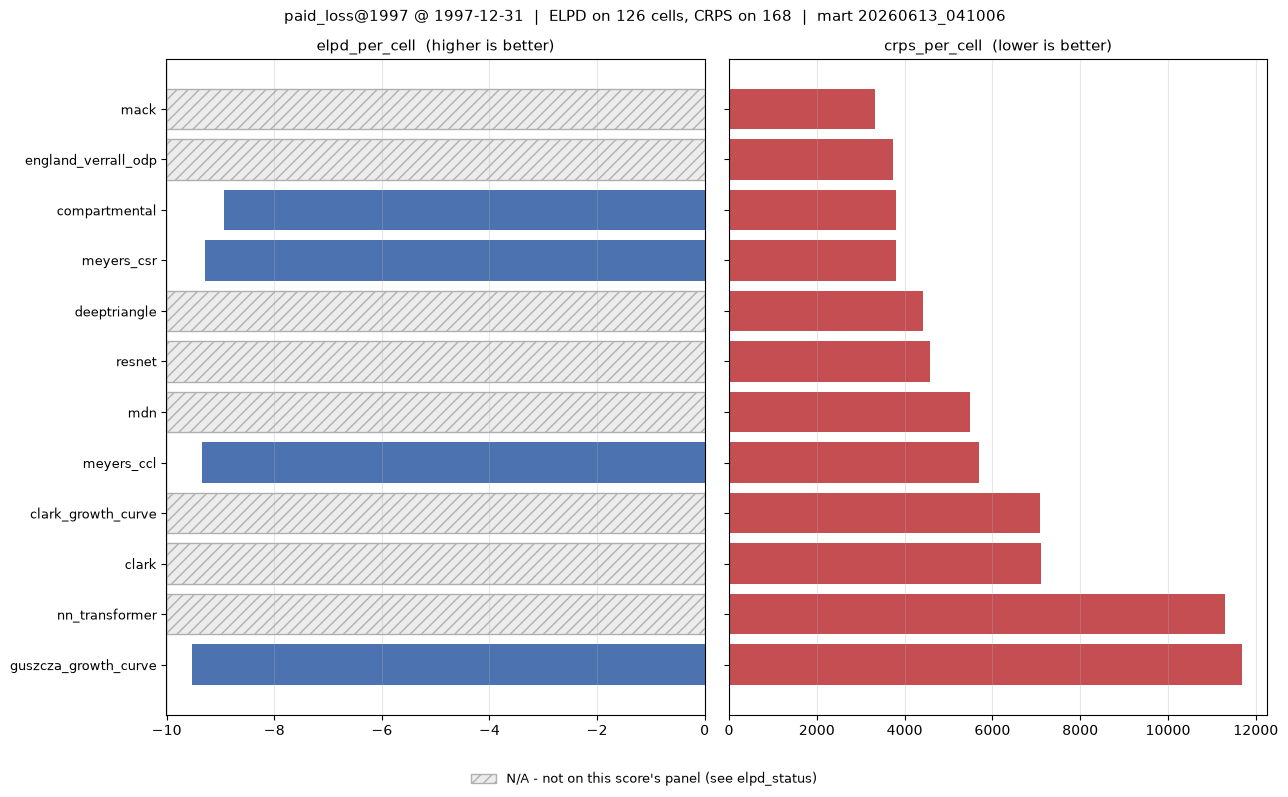

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 0.45 * len(board) + 2.6), sharey=True)
order = board.sort_values("crps_per_cell")["model"].tolist()
y = np.arange(len(order))

for ax, col, direction in zip(
    axes, ["elpd_per_cell", "crps_per_cell"], ["higher is better", "lower is better"]
):
    vals = board.set_index("model").loc[order, col]
    have = vals.notna().to_numpy()
    v = pd.to_numeric(vals, errors="coerce").to_numpy(dtype=float)
    ax.barh(y[have], v[have], color="#4c72b0" if col.startswith("elpd") else "#c44e52")
    if (~have).any():
        # N/A is drawn as an explicit hatched band, never omitted and never plotted as
        # 0: 0 is the best value in BOTH columns. It spans the WHOLE row - a band the
        # width of the data would read as a bar with a value - and it is named once in
        # the figure legend, because per-row text was wider than the band and printed
        # over the y tick labels.
        x0, x1 = ax.get_xlim()
        for j, yy in enumerate(y[~have]):
            ax.barh(
                yy,
                x1 - x0,
                left=x0,
                color="#ececec",
                edgecolor="#b0b0b0",
                hatch="///",
                label="N/A - not on this score's panel (see elpd_status)"
                if j == 0
                else "_nolegend_",
            )
        ax.set_xlim(x0, x1)
    ax.set_yticks(y, order, fontsize=9)
    ax.set_title(f"{col}  ({direction})", fontsize=11)
    ax.axvline(0, color="black", lw=0.6)
    ax.grid(axis="x", alpha=0.3)
axes[0].invert_yaxis()
_handles, _labels = axes[0].get_legend_handles_labels()
if _handles:
    fig.legend(_handles[:1], _labels[:1], loc="lower center", frameon=False, fontsize=9)
fig.suptitle(
    f"{TASK} @ {panel.as_of}  |  ELPD on {panel.n_cells_for('elpd')} cells, "
    f"CRPS on {panel.n_cells_for('crps')}  |  mart {PUBLISH_ID}",
    fontsize=11,
)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

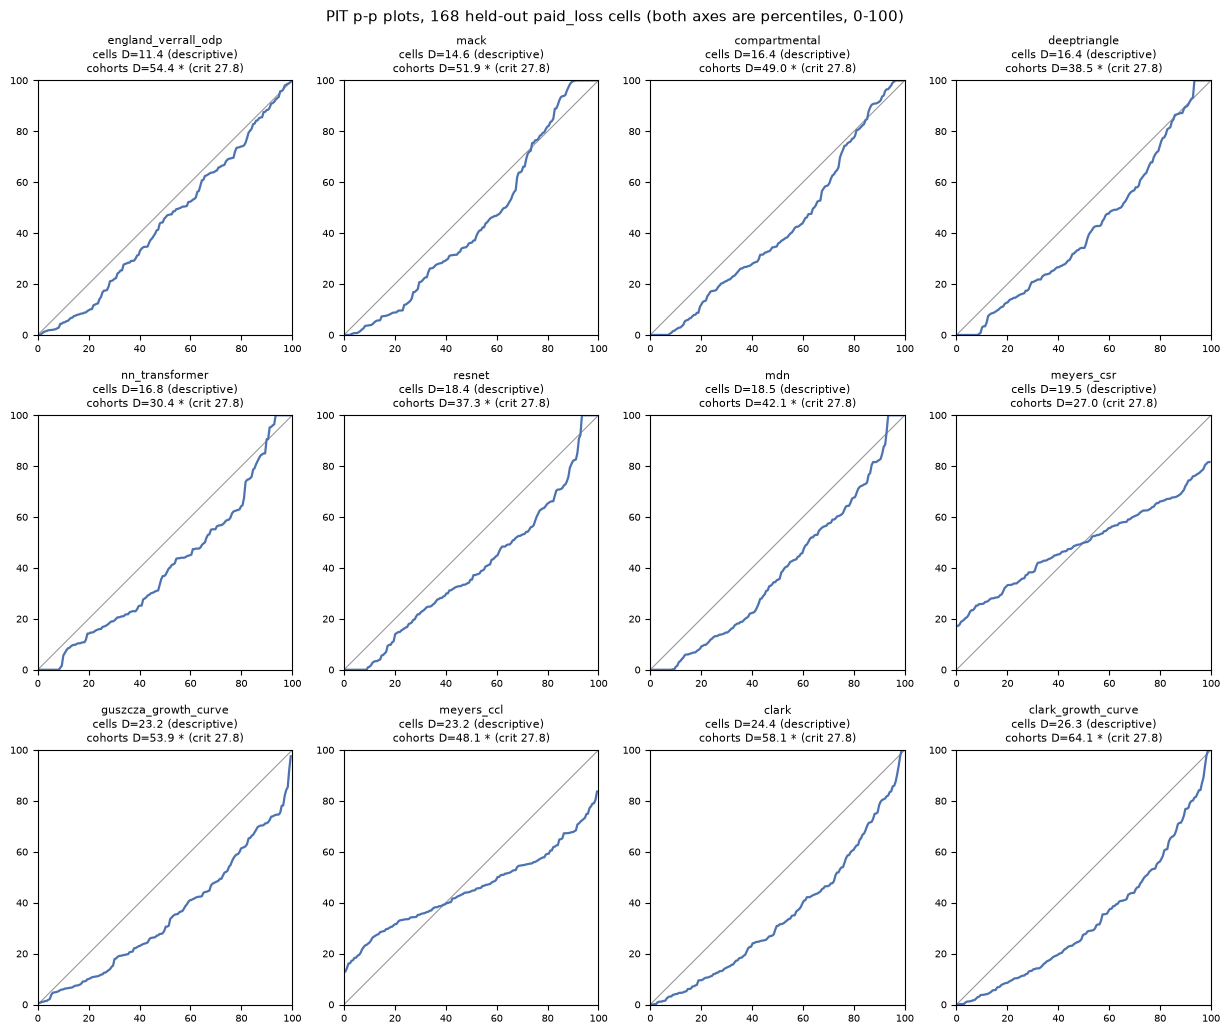

12 panels, [168] points each, on 0-100 axes


In [39]:
# pp_points returns PERCENTILES - (expected * 100, sorted PIT * 100), the Meyers
# convention the published retrospectives print. So the axes and the reference
# diagonal run 0-100 as well. Drawn against a [0, 1] diagonal with xlim/ylim (0, 1),
# every one of these points falls outside the window and the visible line is a
# clipping artifact, not the curve.
#
# The curves are the CELL-level PITs and are descriptive; the asterisk in each
# title is the COHORT-level test, which is the one with a valid null.
models = ks.sort_values("D x 100")["model"].tolist()
ncol = 4
nrow = int(np.ceil(len(models) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 3.5 * nrow), squeeze=False)
n_points = {}
_kc = ks_cohort.set_index("model")
for ax, m in zip(axes.ravel(), models):
    x, y = pp_points(pits[m])
    n_points[m] = len(x)
    ax.plot([0, 100], [0, 100], color="#999999", lw=0.8)
    ax.plot(x, y, lw=1.6, color="#4c72b0")
    r = ks.set_index("model").loc[m]
    rc = _kc.loc[m]
    flag = "" if rc["passes"] else " *"
    ax.set_title(
        f"{m}\ncells D={r['D x 100']:.1f} (descriptive)\n"
        f"cohorts D={rc['D x 100']:.1f}{flag} (crit {rc['critical 5% x 100']:.1f})",
        fontsize=8,
    )
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(models) :]:
    ax.axis("off")
fig.suptitle(
    f"PIT p-p plots, {panel.n_cells_for('crps')} held-out {FIELD} cells "
    "(both axes are percentiles, 0-100)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

# The panels contain their data, and this is what says so rather than the eye.
assert set(n_points.values()) == {panel.n_cells_for("crps")}, n_points
print(f"{len(n_points)} panels, {sorted(set(n_points.values()))} points each, on 0-100 axes")

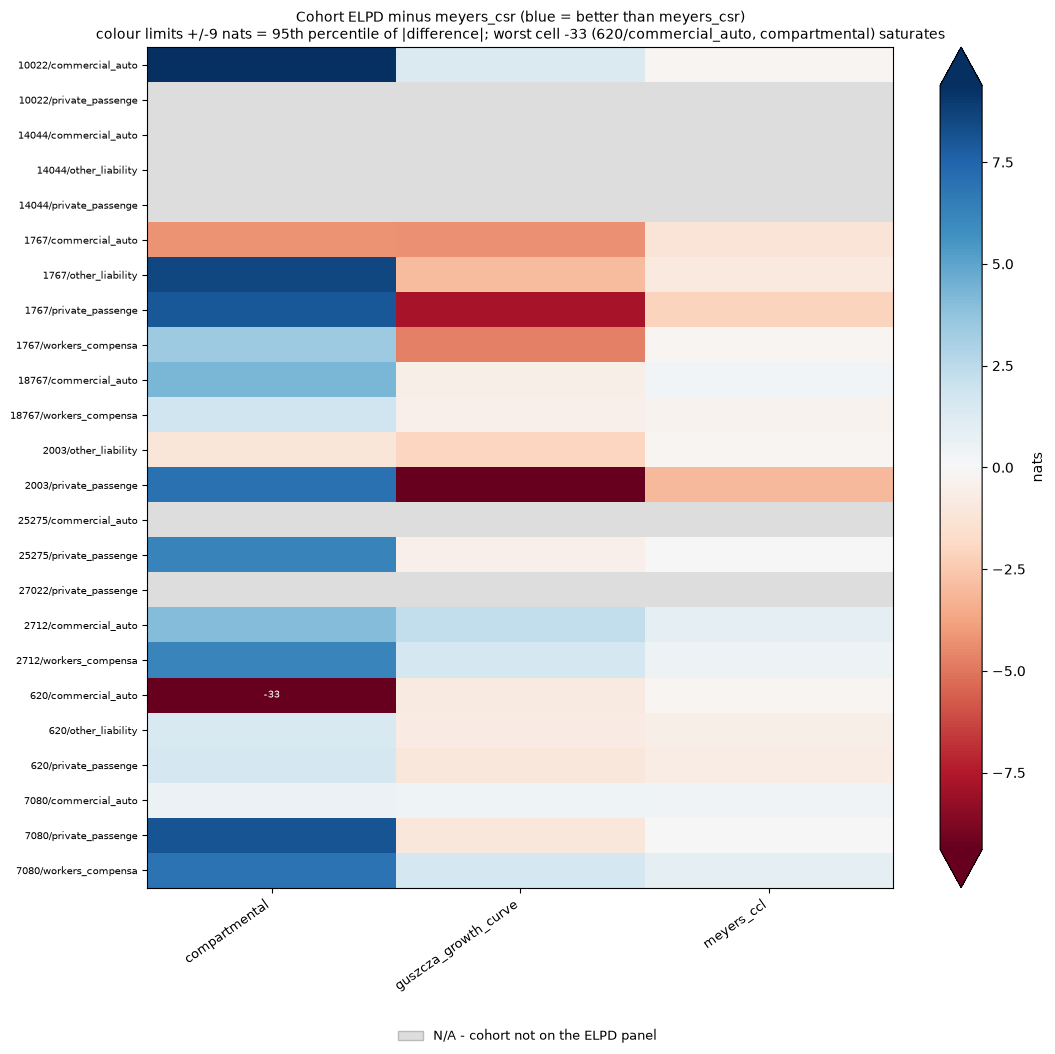

In [40]:
fig, ax = plt.subplots(figsize=(11, 0.34 * len(diff) + 2.4))
data = diff[sorted(diff.columns)]
arr = data.to_numpy(dtype=float)

# NaN here means "this cohort is not on the ELPD panel at all" (compartmental refused
# it), which is NOT a zero difference - so it gets its own grey instead of the
# diverging colormap's white, which is exactly what zero looks like.
cmap = plt.get_cmap("RdBu").with_extremes(bad="#dddddd")
# Robust limits. The worst single cell is about 3x the next worst, and symmetric
# limits off nanmax(|.|) pushed every other cohort to near-white. Anything past the
# limit saturates, and the extreme is labelled on its own cell so it is not lost.
lim = float(np.nanpercentile(np.abs(arr), 95))
im = ax.imshow(arr, aspect="auto", cmap=cmap, vmin=-lim, vmax=lim)
_r, _c = np.unravel_index(np.nanargmin(arr), arr.shape)
ax.text(_c, _r, f"{arr[_r, _c]:.0f}", ha="center", va="center", fontsize=7, color="white")
ax.set_xticks(range(data.shape[1]), data.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(data.shape[0]), data.index, fontsize=7)
ax.set_title(
    f"Cohort ELPD minus {REFERENCE} (blue = better than {REFERENCE})\n"
    f"colour limits +/-{lim:.0f} nats = 95th percentile of |difference|; "
    f"worst cell {arr[_r, _c]:.0f} ({data.index[_r]}, {data.columns[_c]}) saturates",
    fontsize=10,
)
fig.colorbar(im, ax=ax, label="nats", extend="both")
fig.legend(
    handles=[
        Patch(
            facecolor="#dddddd",
            edgecolor="#bbbbbb",
            label="N/A - cohort not on the ELPD panel",
        )
    ],
    loc="lower center",
    frameon=False,
    fontsize=9,
)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## Appendix A: the multiline entries

`sur`, `copula_glm` and `nn_transformer_ml` subclass **neither** held-out mixin, so they
cannot appear in the ELPD or CRPS column at all. They are the entries that model
dependence *across lines*, which is the one thing every model on the board above
structurally cannot do - the single-line transformer's per-line draws are independent -
so they are compared here at the ultimate level instead, one fit per company over that
company's screened lines.

`nn_transformer_ml` is omitted on cost: its autoregressive rollout samples line by line
per calendar diagonal, and a single pooled fit on this 10-company panel ran past 10
minutes without completing when that was measured. It is the one cost in this notebook
quoted from a separate measurement rather than from the timing table at the end. Its
published results are in notebook 02 and in `analysis/results/compare_gallery*.csv`.

In [41]:
ml_rows, corr_rows, ml_failures = [], [], []
t0 = time.perf_counter()
for company, lines in PANEL.items():
    ce = tri.expr
    ctri = tri.filter(ce.company_code == company)
    for name, kwargs in [("sur", {}), ("copula_glm", dict(dev_effect="factor"))]:
        try:
            entry = gallery.fit(name, ctri, loss_field=FIELD, as_of=AS_OF, **kwargs)
        except Exception as exc:
            # sur's FGLS and copula_glm's bootstrap each have documented family
            # limits; a refusal is a result, not a crash.
            ml_failures.append(dict(model=name, company_code=company, error=repr(exc)[:180]))
            continue
        pred = entry.predict(seed=SEED_DRAW)
        outcome = np.asarray(entry.realized_ultimates(ctri), dtype=float)
        labels = pred.targets["label"].astype(str).tolist()
        i = labels.index("total") if "total" in labels else len(labels) - 1
        ml_rows.append(
            dict(
                model=name,
                company_code=company,
                n_lines=len(lines),
                predicted_total=float(pred.mean()[i]),
                sd=float(pred.std()[i]),
                realized_total=outcome[i],
                pct_error=100.0 * (pred.mean()[i] - outcome[i]) / outcome[i],
                outcome_pct=100.0 * float(pred.cdf(outcome)[i]),
            )
        )
        # The quantity the single-line entries cannot produce.
        corr = entry.pooled_corr_ if name == "sur" else entry.corr_
        off = corr[np.triu_indices_from(corr, k=1)]
        corr_rows.append(
            dict(
                model=name,
                company_code=company,
                n_lines=len(lines),
                mean_cross_line_corr=float(np.mean(off)),
                max_abs=float(np.max(np.abs(off))),
            )
        )
        del entry
print(
    f"{len(ml_rows)} multiline fits in {time.perf_counter() - t0:.1f}s; {len(ml_failures)} refusals"
)
for f in ml_failures:
    print("  ", f)
ml = pd.DataFrame(ml_rows)
display(ml.round(2))
display(
    pd.DataFrame(corr_rows)
    .groupby("model")
    .agg(
        companies=("company_code", "nunique"),
        mean_cross_line_corr=("mean_cross_line_corr", "mean"),
        max_abs=("max_abs", "max"),
    )
    .round(3)
)

17 multiline fits in 7.9s; 3 refusals
   {'model': 'copula_glm', 'company_code': '14044', 'error': 'ValueError(\'4 cells have a non-positive increment in some line; lognormal marginals need positive increments - use paid losses, or nonpositive="drop" (biased: it censors the left t'}
   {'model': 'copula_glm', 'company_code': '25275', 'error': 'ValueError(\'7 cells have a non-positive increment in some line; lognormal marginals need positive increments - use paid losses, or nonpositive="drop" (biased: it censors the left t'}
   {'model': 'copula_glm', 'company_code': '27022', 'error': 'ValueError(\'3 cells have a non-positive increment in some line; lognormal marginals need positive increments - use paid losses, or nonpositive="drop" (biased: it censors the left t'}


,model,company_code,n_lines,predicted_total,sd,realized_total,pct_error,outcome_pct
0,sur,10022,2,53498.57,1292.97,52346.0,2.20,18.95
1,copula_glm,10022,2,54252.34,2079.65,52346.0,3.64,18.72
2,sur,14044,3,37593.87,641.78,37281.0,0.84,31.86
3,sur,1767,4,82536284.52,581936.63,81660998.0,1.07,6.35
4,copula_glm,1767,4,82719524.32,592432.85,81660998.0,1.30,2.56
5,sur,18767,2,223047.28,3232.82,210677.0,5.87,0.00
6,copula_glm,18767,2,228583.28,10578.54,210677.0,8.50,0.82
7,sur,2003,2,10789869.88,171792.36,10707190.0,0.77,32.13
8,copula_glm,2003,2,10957892.23,269700.61,10707190.0,2.34,17.34
9,sur,25275,2,83763.15,1166.65,88574.0,-5.43,100.00


,companies,mean_cross_line_corr,max_abs
model,,,
copula_glm,7,0.220,0.714
sur,10,0.091,0.824


## Appendix B: the same machinery on `reported_loss`

`paid_loss` is the headline field because three entries on the board require it -
`copula_glm`'s lognormal marginals cannot take a negative reported increment, and
`meyers_csr` / `england_verrall_odp` / `clark` are paid models by construction. But
`meyers_ccl` is a *reported*-loss model in the monograph, and the paid board under-sells
it.

So: the same 25 cohorts, the same `HoldoutCells` objects (built with both fields
precisely so this costs nothing extra), `field="reported_loss"` - and a **separate panel
and separate board**, because `align_panel` refuses to mix tasks. Summing the densities
of two different quantities into one number would still print.

**`meyers_csr` is off label here and the column says so.** CCL is the monograph's
incurred-loss model and it is what this repo validated on reported loss - the milestone-2
200-company retrospective, net of bulk, passes KS on all four lines and combined. CSR is
the monograph's *paid*-loss model: its changing-settlement-rate parameter is a statement
about how fast claims are **paid down**, and the 200-company retrospective that validated
it here (combined D = 4.1, the best-calibrated paid entry in the gallery) was on paid loss.
Nothing stops it fitting a cumulative reported triangle - the likelihood is the same shape
and the numbers below are real - but they are a **functional-form ablation**, not a
validated result on this basis, and the `basis` column is there so a reader cannot take
the row for one. Keeping it beats dropping it: it is the closest thing the gallery has to
a control for "how much of CCL's reported-loss standing is the CCL structure rather than a
Meyers-style hierarchical lognormal in general".

And the ablation earns its place by not going the convenient way: the off-label CSR
**beats** CCL on this panel, on both columns. That is one 25-cohort panel against a
200-company retrospective, so it moves nothing about which entry is validated where -
but it is the reason the row is labelled rather than deleted. An ablation you only keep
when it loses is not a control.

This is deliberately not extended to the rest of the gallery: reported loss net of bulk
can decrease, which neither the ODP quasi-likelihood nor a lognormal increment accepts,
and a second full pass would cost another half hour.


In [42]:
if RUN_REPORTED_APPENDIX:
    rep_forecasts, rep_seconds = [], {}
    for name in ["meyers_ccl", "meyers_csr"]:
        t0 = time.perf_counter()
        for key in COHORTS:
            try:
                entry = gallery.fit(
                    name,
                    sub[key],
                    loss_field="reported_loss",
                    as_of=AS_OF,
                    seed=SEED_FIT,
                    parallel_chains=4,
                )
            except Exception as exc:
                rep_forecasts.append(
                    CohortForecast.unavailable(
                        model=name,
                        task="reported_loss@1997",
                        cells=cells[key],
                        field="reported_loss",
                        density_reason="fit_failed",
                        draws_reason="fit_failed",
                        detail=f"{type(exc).__name__}: {exc}"[:150],
                    )
                )
                continue
            rep_forecasts.append(
                forecast_for(name, entry, key, field="reported_loss", task="reported_loss@1997")
            )
            del entry
        rep_seconds[name] = round(time.perf_counter() - t0, 1)
        print(f"{name:14s} {rep_seconds[name]:6.1f}s", flush=True)
    rep_panel = align_panel(rep_forecasts, units=tri.meta.units)
    print()
    print(repr(rep_panel))
    rep_board = gallery.leaderboard(rep_panel)
    # The label is part of the result. CSR is the monograph's PAID model and its
    # 200-company retrospective here was on paid; running it on reported is an
    # ablation of the functional form, not a validated use.
    BASIS = {
        "meyers_ccl": "on label - the monograph's incurred model",
        "meyers_csr": "OFF LABEL - monograph + retro validate CSR on PAID",
    }
    _rep_view = rep_board[
        [
            "model",
            "n_cells_elpd",
            "elpd",
            "elpd_per_cell",
            "min_ess_kish",
            "n_cells_crps",
            "crps",
            "crps_per_cell",
        ]
    ].round(3)
    _rep_view.insert(1, "basis", _rep_view["model"].map(BASIS))
    assert _rep_view["basis"].notna().all(), "an entry joined the appendix with no basis label"
    display(_rep_view)
else:
    rep_seconds = {}
    print("reported appendix skipped (RUN_REPORTED_APPENDIX = False)")

meyers_ccl       54.8s


meyers_csr       57.6s



ForecastPanel(reported_loss@1997 @ 1997-12-31, 2 models, 25 cohorts | elpd: 175 cells over ['meyers_ccl', 'meyers_csr'] | crps: 175 cells over ['meyers_ccl', 'meyers_csr'] | dropped=0)


,model,basis,n_cells_elpd,elpd,elpd_per_cell,min_ess_kish,n_cells_crps,crps,crps_per_cell
0,meyers_ccl,on label - the monograph's incurred model,175,-1471.486,-8.408,1189.105,175,902800.551,5158.86
1,meyers_csr,OFF LABEL - monograph + retro validate CSR on ...,175,-1457.666,-8.33,1093.775,175,769170.62,4395.261


## What this notebook does not claim

1. **It is a demonstration, not a study.** 10 companies, 25 cohorts, 175 held-out cells,
   one cutoff, one field. Rankings on a panel this small move with the panel. The
   evidence is the 200-company retrospectives in `analysis/results/` and notebook 02.
2. **The cohorts are not a random sample of the mart.** They passed the Meyers stability
   screens and were then filtered to companies with no negative paid increment anywhere
   in the training slice, so `england_verrall_odp` could stay on the board without
   deleting cohorts from everyone else. Well-behaved data flatters every model here, and
   flatters the ones with the strongest positivity assumptions most.
3. **The NN entries run cut down, and they have no ELPD column at all.** 120 epochs and
   5 ensemble members against the published study's 400 epochs. Separately from the
   budget, their held-out density is refused on every cohort of a provenance-consistent
   panel, because the deepest scored cell is always a pinned development step - so the
   ELPD column here is four MCMC entries and the NN family is compared on CRPS, PIT and
   point error only. Reading their absence from the ELPD column as a verdict on their
   densities would be wrong; it is a verdict on this held-out design.
4. **`guszcza_growth_curve` and `compartmental` run at reduced budgets** (4x1000 rather
   than 4x2500) and `compartmental` at the harness's relaxed sampler
   (`target_accept=0.9`, `max_treedepth=12`, not the monograph's 0.99 / 15). Same
   estimands, more Monte Carlo error, and for compartmental a small number of divergent
   transitions the monograph settings would remove.
5. **The study window is eight accident years, 1990-1997, and that is a choice.** The
   triangle is cut to them before any fit, so the fits are smaller than a 1988-1997 study
   would make them and the board loses the two deepest development lags - which are
   exactly where a growth-curve or CSR-style model is most distinctive. What the window
   is NOT is a scoring-only restriction: cutting it into the data is what makes
   `HoldoutCells.train_origins` a true statement about every fit.
6. **No stacking.** `kernels.stacking` needs a weights panel at an earlier cutoff plus an
   evaluation panel at the later one, which means fitting every density member twice.
   That belongs in its own notebook once this leaderboard is settled.
7. **The NN rows did not see the same information as the rows they are ranked
   against.** The four NN entries are fitted **once, pooled over all 25 cohorts**,
   while `mack`, `clark`, `meyers_ccl`, `meyers_csr`, `england_verrall_odp`,
   `clark_growth_curve`, `guszcza_growth_curve` and `compartmental` are each fitted on
   a single cohort's triangle. Every NN row therefore reaches its board position
   having seen roughly 25 times the loss history of the rows beside it. That is how
   these architectures are meant to be used - one Schedule P triangle is far too small
   to train one, which is the whole finding of the NN literature - but it makes this
   board an asymmetric-information comparison rather than a like-for-like one, and no
   panel object can correct for it. It also flatters the timing table, where a pooled
   fit's cost is amortized over 25 cohorts while every Stan row pays per cohort.
8. **The cell-level KS statistics are descriptive, and the cohort-level test is weak.**
   168 held-out cells are not 168 independent observations, so no critical value is
   quoted against them. The cohort-level test that does carry a critical value has one
   observation per cohort, cohorts of the same company are still correlated, and at
   n = 24 it detects only gross miscalibration - which, on this run, is what it finds:
   it rejects eleven of the twelve entries, with every mean cohort PIT well below 0.5.
   A rejection there is informative; the ordering among the eleven is not. Neither
   number is a substitute for the 200-company retrospectives, where the PIT sample is
   the study.


In [43]:
timings = (
    pd.DataFrame(
        [
            {"entry": k, "seconds": v, "seconds_per_cohort": round(v / len(COHORTS), 2)}
            for k, v in fit_seconds.items()
        ]
        + [
            {
                "entry": f"{k} (reported)",
                "seconds": v,
                "seconds_per_cohort": round(v / len(COHORTS), 2),
            }
            for k, v in rep_seconds.items()
        ]
    )
    .sort_values("seconds", ascending=False)
    .reset_index(drop=True)
)
display(timings)
print(
    f"total fitting: {timings['seconds'].sum() / 60:.1f} min "
    f"(+ {sum(compile_seconds.values()) / 60:.1f} min Stan compilation)"
)
print()
print("mart publish_id ", PUBLISH_ID)
print("ELPD fingerprint", panel.elpd_fingerprint, "|", panel.n_cells_for("elpd"), "cells")
print("CRPS fingerprint", panel.crps_fingerprint, "|", panel.n_cells_for("crps"), "cells")
print("ibnr            ", ibnr.__version__)
print("python          ", sys.version.split()[0])
print("platform        ", platform.platform())
print("numpy/pandas    ", np.__version__, pd.__version__)

,entry,seconds,seconds_per_cohort
0,compartmental,477.6,19.10
1,guszcza_growth_curve,201.6,8.06
2,clark_growth_curve,64.3,2.57
3,meyers_csr,61.9,2.48
4,meyers_ccl,59.9,2.40
5,meyers_csr (reported),57.6,2.30
6,meyers_ccl (reported),54.8,2.19
7,england_verrall_odp,49.2,1.97
8,nn_transformer,38.4,1.54
9,deeptriangle,32.8,1.31


total fitting: 19.3 min (+ 0.0 min Stan compilation)

mart publish_id  20260613_041006
ELPD fingerprint 0bd1e6212c5c56f2 | 126 cells
CRPS fingerprint 468d769145503ba4 | 168 cells
ibnr             0.5.2
python           3.12.13
platform         Windows-11-10.0.26200-SP0
numpy/pandas     2.4.6 2.3.3
